<a href="https://colab.research.google.com/github/matteogorni2/Automated-social-media-videos-analysis-with-MLLMs/blob/master/results_analysis_and_plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Video annotator post processing pipeline
questo notebook è una prima iterazione di quella che potrebbe essere l'analisi dei nostri dati una volta che abbiamo fatto le analisi e ottenuto le annotazioni per tutti i video!


Definiamo l'analisi in più livelli. idea.
settori: il notebook è diviso su vari livelli che fanno studi su diferse prospettive.

1.   Introduzione, esploriamo un pò le labels prodotte e le visualizziamo

2.   gender, facciamo studio per vedere se ci sono differenze fra label e genere

1.   Nazione, analisi differenze fra nazione
2.   testo: ci facciamo qualche analisi statistica







## loading dataframe and importing packages


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Magic command for embedding plots
%matplotlib inline

# Default styling for screen viewing
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (10, 6)    # Width, height in inches
plt.rcParams['figure.dpi'] = 80           # Screen-friendly resolution
plt.rcParams['font.size'] = 11              # Readable font size
plt.rcParams['axes.grid'] = True            # Subtle grid lines
plt.rcParams['grid.alpha'] = 0.3

In [ ]:
%%capture
import pandas as pd
import matplotlib.ticker as mtick
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
from pathlib import Path
from scipy.stats import mannwhitneyu

!pip install pingouin
import pingouin as pg


In [ ]:
dataset_path = Path("/content/drive/MyDrive/thesis_data/video analysis/lavoro_matteo/data/lavoro_matteo_dataset_completo.xlsx")

In [ ]:
df=pd.read_excel(dataset_path)


In [ ]:
df.groupby('gender').size()

,0
gender,
man,8808
"man, other",89
mixed,670
other,671
woman,7593
"woman,other",29


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17889 entries, 0 to 17888
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   touch                 17889 non-null  int64  
 1   pose                  17889 non-null  int64  
 2   clothing_nudity       17889 non-null  int64  
 3   video_name            17889 non-null  object 
 4   Video_Category        17886 non-null  object 
 5   Revised_Desc          17886 non-null  object 
 6   nation                17889 non-null  object 
 7   username              17889 non-null  object 
 8   id                    17889 non-null  int64  
 9   create_time           17889 non-null  object 
 10  video_size            17889 non-null  float64
 11  video_url             17889 non-null  object 
 12  video_plays           17889 non-null  int64  
 13  video_script          6115 non-null   object 
 14  post_text             16488 non-null  object 
 15  post_shares        

In [ ]:
df.head

## feature engineering
in questa sezione modifico il dataframe con l'obiettivo di creare variabili più informative, chiaramente è tutto ipotetico e necessita di review

In [ ]:
# Calculate ratios with safe division (avoid inf/nan at source)
df['shares_per_play'] = np.where(
    df['video_plays'] != 0,
    df['post_shares'] / df['video_plays'],
    0.0
)

df['comments_per_play'] = np.where(
    df['video_plays'] != 0,
    df['comment_count'] / df['video_plays'],
    0.0
)

df['downloads_per_play'] = np.where(
    df['video_plays'] != 0,
    df['comment_downl'] / df['video_plays'],
    0.0
)

df['overall_sexualisation_score']=df['touch']+df['pose']+df['clothing_nudity']
# Optional: explicitly clamp any remaining inf/-inf to 0 (defensive)
for col in ['shares_per_play', 'comments_per_play', 'downloads_per_play']:
    df[col] = df[col].replace([float('inf'), float('-inf')], 0.0).fillna(0.0)

In [ ]:
df.head()

,touch,pose,clothing_nudity,video_name,Video_Category,Revised_Desc,nation,username,id,create_time,...,followingCount,followerCount,heartCount,videoCount,diggCount,heart,shares_per_play,comments_per_play,downloads_per_play,overall_sexualisation_score
0,1,0,2,@.eslis_video_7508127550544071967,Social Media Comedy,"A young woman with long dark hair, wearing a r...",us,.eslis,7508127550544071680,2025-05-24,...,113.0,6523351.0,407730136.0,798.0,40150.0,407730136.0,0.001277,0.000106,0.000009,3
1,0,0,0,@.eslis_video_7513559348262489374,Social Media Skit,A young woman with long dark hair and a camouf...,us,.eslis,7513559348262489088,2025-06-08,...,113.0,6523351.0,407730136.0,798.0,40150.0,407730136.0,0.010511,0.000806,0.000012,0
2,1,1,0,@.eslis_video_7520825570112834846,Lifestyle/Dance,A young woman with long dark hair and glasses ...,us,.eslis,7520825570112834560,2025-06-28,...,113.0,6523351.0,407730136.0,798.0,40150.0,407730136.0,0.001210,0.000512,0.000017,2
3,1,1,1,@.eslis_video_7531153504535170335,Social Media Skit,The video opens in a brightly lit cafeteria wi...,us,.eslis,7531153504535170048,2025-07-25,...,113.0,6523351.0,407730136.0,798.0,40150.0,407730136.0,0.000806,0.000217,0.000015,3
4,1,0,2,@.eslis_video_7539338888372964639,Social Media Comedy Skit,A young woman with long dark hair styled in tw...,us,.eslis,7539338888372964352,2025-08-17,...,113.0,6523351.0,407730136.0,798.0,40150.0,407730136.0,0.010781,0.000869,0.000012,3


In [ ]:
desc_len = df["Revised_Desc"].fillna("").astype(str).str.split().str.len()


In [ ]:
desc_len.describe()

,Revised_Desc
count,17889.000000
mean,181.504220
std,65.264525
min,0.000000
25%,140.000000
50%,166.000000
75%,205.000000
max,1107.000000


In [ ]:
df[df['overall_sexualisation_score']==11]

,touch,pose,clothing_nudity,video_name,Video_Category,Revised_Desc,nation,username,id,create_time,...,followingCount,followerCount,heartCount,videoCount,diggCount,heart,shares_per_play,comments_per_play,downloads_per_play,overall_sexualisation_score
8076,3,3,5,@unrestt_video_7422222468007382279,Cartoon/Animation,A simple black-and-white animated character wi...,kr,unrestt,7422222468007382016,2024-10-05,...,40.0,656515.0,28167541.0,127.0,37549.0,28167541.0,0.000337,0.000643,0.000345,11
9089,3,3,5,@wildwild_official_video_7510141333089094920,Music Video,The video opens with close-up shots of a glist...,kr,wildwild_official,7510141333089094656,2025-05-30,...,0.0,548313.0,12183842.0,218.0,91.0,12183842.0,0.057800,0.003517,0.000097,11
13854,3,3,5,@sighkeeeee_video_7416409472593104160,Family/Personal Moment,A shirtless person with dark curly hair and vi...,it,sighkeeeee,7416409472593103872,2024-09-19,...,967.0,1835298.0,87226667.0,924.0,453035.0,87226667.0,0.003612,0.000651,0.000445,11
14870,3,3,5,@thebissholes__video_7528755851985784086,Comedy Sketch,The video opens in a cluttered room with shelv...,it,thebissholes_,7528755851985783808,2025-07-19,...,584.0,665912.0,28000980.0,330.0,21516.0,28000980.0,0.005516,0.000599,0.000118,11
15096,3,3,5,@beatrice.macconi_video_7471255696655568150,Comedy Sketch,The video opens with a man in a white t-shirt ...,it,beatrice.macconi,7471255696655567872,2025-02-14,...,1218.0,918111.0,46849495.0,1069.0,66914.0,46849495.0,0.004671,0.000168,0.000104,11


## plotting functions


In [ ]:
%matplotlib inline
def plot_category_distribution(df, cat_col, normalize=True):
    """
    Bar plot of category distribution.
    """
    counts = df[cat_col].value_counts(dropna=False)
    values = counts / counts.sum() if normalize else counts

    plt.figure(figsize=(6, 4))
    plt.bar(values.index.astype(str), values.values)
    plt.xlabel(cat_col)
    plt.ylabel("proportion" if normalize else "count")
    plt.title(f"{cat_col} distribution")
    plt.tight_layout()
    plt.show()

    return counts.to_frame("count")

def category_performance_summary(
    df,
    cat_col,
    metric="video_plays"
):
    """
    Aggregated statistics of a numeric metric grouped by a categorical label.
    """
    summary = (
        df.groupby(cat_col)[metric]
        .agg(["count", "mean", "median", "std"])
        .sort_values("mean", ascending=False)
    )

    return summary

def plot_metric_by_category(df, cat_col, metric,format_yaxis=None,log_scale=False):
    """
    Boxplot of a metric grouped by category.
    """
    categories = sorted(df[cat_col].dropna().unique())

    data = [
        df.loc[df[cat_col] == c, metric].dropna()
        for c in categories
    ]

    plt.figure(figsize=(7, 4))
    plt.boxplot(data, labels=[str(c) for c in categories], showfliers=True)
    plt.xlabel(cat_col)
    plt.ylabel(metric)
    plt.title(f"{metric} by {cat_col}")
    if log_scale:
        plt.yscale("log")
    if format_yaxis is not None:
        apply_yaxis_formatting(format_yaxis, metric_name=metric)
    plt.tight_layout()
    plt.show()


def apply_yaxis_formatting(
    option,
    metric_name=None
):
    """
    option: one of {"plain", "millions", "pretty"}
    metric_name: string used to relabel the y-axis (optional)
    """

    ax = plt.gca()

    if option == "plain":
        # Option 1: disable scientific notation
        ax.ticklabel_format(axis="y", style="plain")

    elif option == "millions":
        # Option 2: rescale to millions
        ax.yaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x, _: x / 1e6)
        )
        if metric_name is not None:
            ax.set_ylabel(f"{metric_name} (millions)")

    elif option == "pretty":
        # Option 3: 1.2M / 850K formatting
        def pretty_fmt(x, _):
            if x >= 1e6:
                return f"{x/1e6:.1f}M"
            elif x >= 1e3:
                return f"{x/1e3:.0f}K"
            else:
                return str(int(x))

        ax.yaxis.set_major_formatter(mtick.FuncFormatter(pretty_fmt))

    else:
        raise ValueError(
            "option must be one of {'plain', 'millions', 'pretty'}"
        )


In [ ]:
def create_boxplot(df,x_value,y_value):
  sns.boxplot(x=x_value, y=y_value, data=df)
  plt.title(f"{y_value} by {x_value}")
  plt.xlabel(x_value)
  plt.ylabel(y_value)
  plt.show()

def create_scatterplot(df,x_value,y_value):
  sns.scatterplot(
      data=df,
      x=x_value,
      y=y_value,
      alpha=0.3
  )

def create_barplot(df, value_col, group_col, figsize=(12,6), cmap="viridis"):
    """
    Create a stacked barplot showing the distribution of `value_col` across `group_col`.

    Parameters:
    - df : pd.DataFrame
    - value_col : str, column with values to analyze (ordinal/categorical)
    - group_col : str, column to group by (categorical)
    - figsize : tuple, figure size
    - cmap : str, colormap for bars
    """

    ct = pd.crosstab(df[value_col], df[group_col])
    ct_pct = ct.div(ct.sum(axis=0), axis=1)
    ct_pct.T.plot(kind="bar", stacked=True, figsize=figsize, colormap=cmap)
    plt.ylabel("Proportion")
    plt.xlabel(group_col)
    plt.title(f"Distribution of {value_col} by {group_col}")
    plt.legend(title=value_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

def create_countplot(df, value_col, group_col, figsize=(12,6), palette="viridis"):
    ct = pd.crosstab(df[value_col], df[group_col])
    ct.T.plot(kind="bar", stacked=True, figsize=figsize, colormap=palette)
    plt.ylabel("Count")
    plt.xlabel(group_col)
    plt.title(f"Counts of {value_col} by {group_col}")
    plt.legend(title=value_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


def create_violinplot(df, value_col, group_col, figsize=(12,6), palette="viridis"):
    plt.figure(figsize=figsize)
    sns.violinplot(data=df, x=group_col, y=value_col, palette=palette, inner="box")
    plt.title(f"Distribution of {value_col} by {group_col}")
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_metric_by_category_faceted(
    df,
    cat_col,
    metric,
    nation_col="nation",
    log_scale=False,
    figsize=(12, 4)
):
    nations = sorted(df[nation_col].dropna().unique())
    categories = sorted(df[cat_col].dropna().unique())

    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)

    for ax, nation in zip(axes, nations):
        subset = df[df[nation_col] == nation]

        data = [
            subset.loc[subset[cat_col] == c, metric].dropna()
            for c in categories
        ]

        ax.boxplot(
            data,
            labels=[str(c) for c in categories],
            showfliers=True
        )

        ax.set_title(nation)
        ax.set_xlabel(cat_col)

        if log_scale:
            ax.set_yscale("log")

    axes[0].set_ylabel(metric)
    fig.suptitle(f"{metric} by {cat_col} (faceted by nation)", y=1.05)

    plt.tight_layout()
    plt.show()

In [ ]:

def categorical_interaction(df, col1, col2):
    """
    Contingency table + chi-square test for two categorical variables using scipy.
    """
    contingency = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, _ = chi2_contingency(contingency)

    return contingency, chi2, p

def plot_categorical_interaction(contingency, chi2=None, p=None):
    plt.figure(figsize=(8,6))
    annot = contingency.values
    sns.heatmap(contingency, annot=annot, fmt="d", cmap="Blues", cbar=False)
    #plt.title("Contingency Table Heatmap")
    if chi2 is not None and p is not None:
        plt.suptitle(f"Chi² = {chi2:.2f}, p = {p:.4f}", y=0.92, fontsize=12)
    plt.ylabel(contingency.index.name)
    plt.xlabel(contingency.columns.name)
    plt.tight_layout()
    plt.show()

In [ ]:
def run_semantic_label_pipeline(df, cat_col):
    plot_category_distribution(df, cat_col)
    plot_metric_by_category(df, cat_col, "post_shares",format_yaxis="pretty")
    plot_metric_by_category(df, cat_col, "shares_per_play",log_scale=True)
    plot_metric_by_category(df, cat_col, "downloads_per_play",log_scale=True)
    plot_metric_by_category(df, cat_col, "video_plays",format_yaxis="pretty")
    return category_performance_summary(df, cat_col)


/tmp/ipykernel_1011/1706907295.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1011/1706907295.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1011/1706907295.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


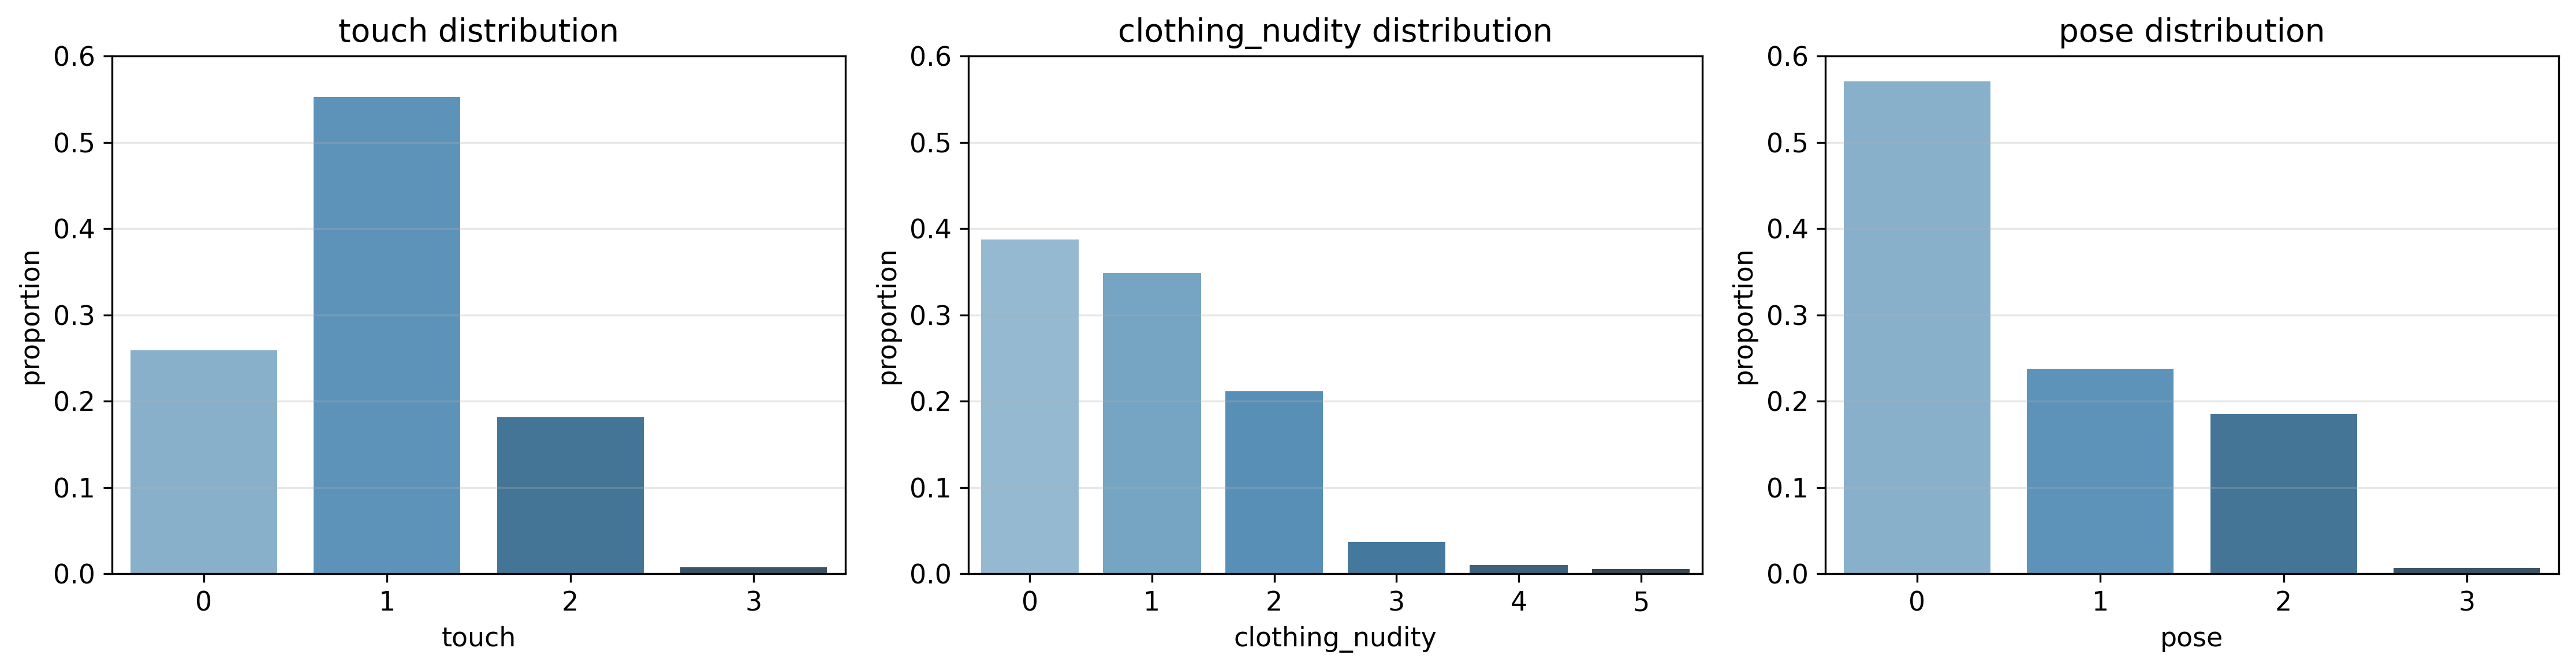

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4),dpi=300)

for i, col in enumerate(['touch', 'clothing_nudity', 'pose']):
    # Calculate proportions
    props = df[col].value_counts(normalize=True).reset_index()
    props.columns = ['category', 'proportion']

    # Plot with seaborn (automatically treats x as categorical)
    sns.barplot(
        data=props,
        x='category',
        y='proportion',
        ax=axes[i],
        palette='Blues_d'
    )
    axes[i].set_title(f'{col} distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('proportion')
    axes[i].set_ylim(0, 0.6)  # Optional: set consistent y-axis

plt.tight_layout()
plt.show()

# exploring the results
in this section i conduct a simple exploration trying to gather info regarding the data we collected


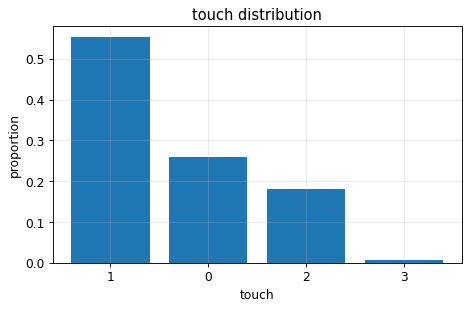

touch
1    9880
0    4633
2    3247
3     129
Name: count, dtype: int64


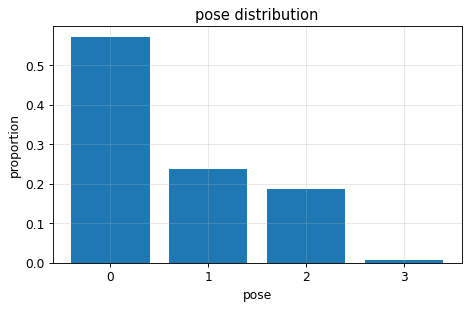

pose
0    10202
1     4250
2     3321
3      116
Name: count, dtype: int64


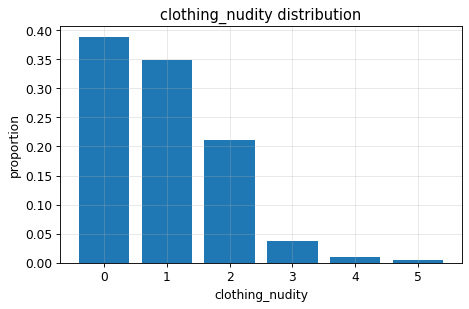

clothing_nudity
0    6933
1    6234
2    3781
3     663
4     184
5      94
Name: count, dtype: int64


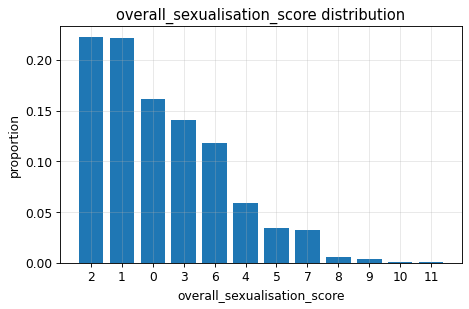

overall_sexualisation_score
2     3975
1     3967
0     2891
3     2524
6     2106
4     1054
5      613
7      579
8      106
9       60
10       9
11       5
Name: count, dtype: int64


In [ ]:
col_names=[
    'touch',
    'pose',
    'clothing_nudity',
    'overall_sexualisation_score'
]

for name in col_names:
  plot_category_distribution(df, name)
  print(df[name].value_counts())

In [ ]:
contingency, chi2, p = categorical_interaction(df, "touch", "pose")
plot_categorical_interaction(contingency, chi2, p)

#Content coding results analysis


##aggregating user data

In [ ]:

group_cols = ['username', 'gender', 'nation']

grouped = df.groupby(group_cols)

# Example 1: get counts of videos per user
user_counts = grouped.size().reset_index(name='num_videos')

# Example 2: get mean of numeric metrics per user
user_means = grouped[['overall_sexualisation_score', 'touch', 'pose', 'clothing_nudity',
                      'followingCount', 'followerCount', 'heartCount', 'shares_per_play','downloads_per_play','comments_per_play']].mean().reset_index()

# Merge counts and means if needed
user_summary = user_counts.merge(user_means, on=group_cols)

user_summary.head()

,username,gender,nation,num_videos,overall_sexualisation_score,touch,pose,clothing_nudity,followingCount,followerCount,heartCount,shares_per_play,downloads_per_play,comments_per_play
0,.eslis,woman,us,29,2.068966,0.827586,0.413793,0.827586,113.0,6523351.0,407730136.0,0.006315,0.000012,0.000746
1,.saiho4,woman,kr,29,2.034483,0.896552,0.241379,0.896552,132.0,2781325.0,256365092.0,0.001536,0.000028,0.000459
2,1eesky,man,kr,29,2.310345,1.034483,0.931034,0.344828,210.0,3079852.0,33455424.0,0.000806,0.002599,0.003336
3,1millionofficial,other,kr,30,4.800000,1.566667,1.566667,1.666667,51.0,1820389.0,27725180.0,0.002002,0.000137,0.000398
4,2180107176naa,woman,kr,30,4.500000,1.433333,1.333333,1.733333,9059.0,1038236.0,8871926.0,0.003533,0.003097,0.007181


In [ ]:
user_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 612 entries, 0 to 611
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   username                     612 non-null    object 
 1   gender                       612 non-null    object 
 2   nation                       612 non-null    object 
 3   num_videos                   612 non-null    int64  
 4   overall_sexualisation_score  612 non-null    float64
 5   touch                        612 non-null    float64
 6   pose                         612 non-null    float64
 7   clothing_nudity              612 non-null    float64
 8   followingCount               612 non-null    float64
 9   followerCount                612 non-null    float64
 10  heartCount                   612 non-null    float64
 11  shares_per_play              612 non-null    float64
 12  downloads_per_play           612 non-null    float64
 13  comments_per_play   

In [ ]:
user_summary.groupby(['nation','gender']).size()

nation  gender     
it      man            107
        mixed            5
        other            6
        woman           82
kr      man             94
        mixed            1
        other           15
        woman           90
us      man            100
        man, other       3
        mixed           17
        other            2
        woman           89
        woman,other      1
dtype: int64

##gender analysis


In [ ]:
user_df_binary_gender=user_summary[user_summary['gender'].isin(['man','woman'])]

In [ ]:
user_df_binary_gender.groupby(['gender']).size()

,0
gender,
man,301
woman,261


In [ ]:
user_df_binary_gender.head()

,username,gender,nation,num_videos,overall_sexualisation_score,touch,pose,clothing_nudity,followingCount,followerCount,heartCount,shares_per_play,downloads_per_play,comments_per_play
0,.eslis,woman,us,29,2.068966,0.827586,0.413793,0.827586,113.0,6523351.0,407730136.0,0.006315,0.000012,0.000746
1,.saiho4,woman,kr,29,2.034483,0.896552,0.241379,0.896552,132.0,2781325.0,256365092.0,0.001536,0.000028,0.000459
2,1eesky,man,kr,29,2.310345,1.034483,0.931034,0.344828,210.0,3079852.0,33455424.0,0.000806,0.002599,0.003336
4,2180107176naa,woman,kr,30,4.500000,1.433333,1.333333,1.733333,9059.0,1038236.0,8871926.0,0.003533,0.003097,0.007181
5,33__72,man,kr,30,1.300000,0.833333,0.233333,0.233333,772.0,1175698.0,29539328.0,0.001341,0.001497,0.005769


In [ ]:
# Check sample sizes per gender × nation cell
cell_sizes = user_df_binary_gender.groupby(['gender', 'nation']).size().unstack(fill_value=0)
print("Sample sizes per gender × nation cell:")
print(cell_sizes)
print("\nMinimum cell size:", cell_sizes.min().min())
print("Total users:", len(user_df_binary_gender))

Sample sizes per gender × nation cell:
nation   it  kr   us
gender              
man     107  94  100
woman    82  90   89

Minimum cell size: 82
Total users: 562


The following analysis compares male and female creators using the Mann–Whitney U test, a non-parametric test for comparing two independent groups with ordinal or non-normal data.

The test output reports:

U_VAL – Mann–Whitney U statistic. Reflects how the ranks of the two groups compare; the basis of the test.

ALTERNATIVE – Indicates the type of hypothesis tested (usually two-sided, meaning we check for any difference between groups).

P_VAL – p-value. Probability of observing the data if the groups are actually the same. Low values suggest a significant difference.

RBC – Rank-Biserial Correlation. Effect size showing how strongly the two groups differ; values near ±1 indicate a strong effect.

CLES – Common Language Effect Size. Probability that a randomly selected value from one group is larger than a value from the other group.

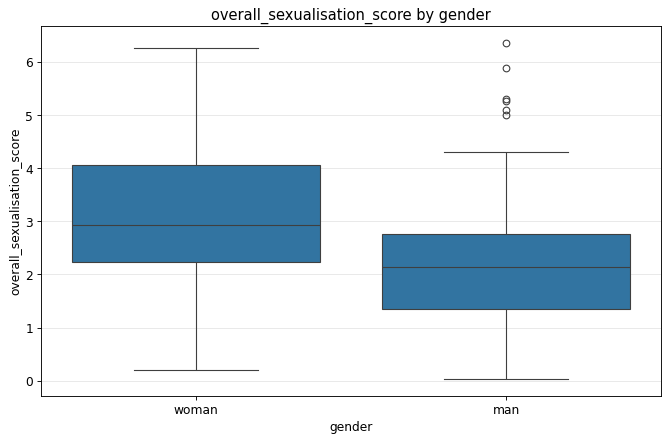

       U_val alternative         p_val       RBC      CLES
MWU  21104.5   two-sided  2.870420e-21 -0.462723  0.268638


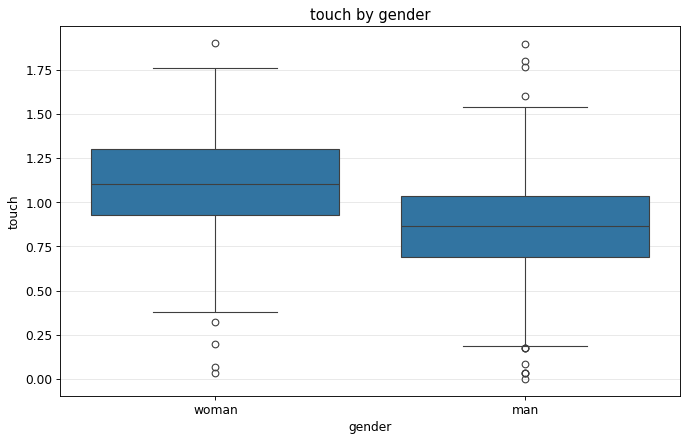

       U_val alternative         p_val       RBC      CLES
MWU  21221.5   two-sided  5.036831e-21 -0.459745  0.270128


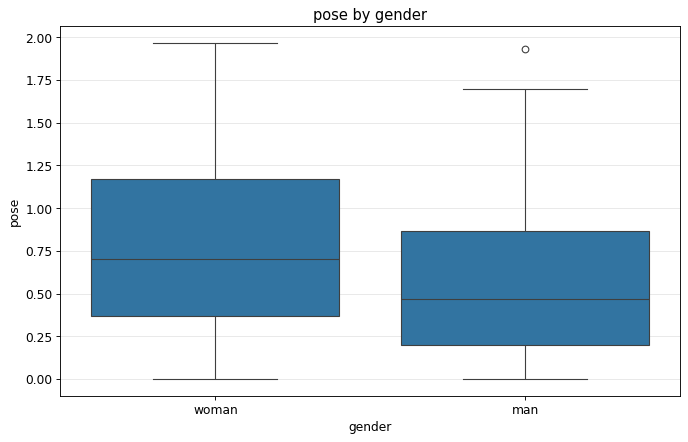

       U_val alternative         p_val       RBC      CLES
MWU  28756.0   two-sided  4.195070e-08 -0.267932  0.366034


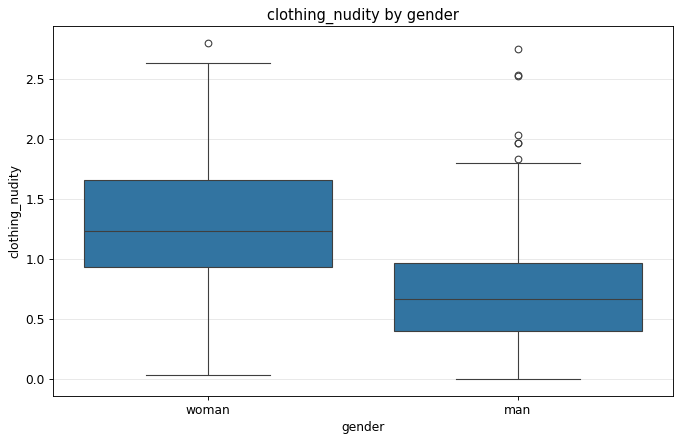

       U_val alternative         p_val       RBC      CLES
MWU  16071.5   two-sided  1.199418e-33 -0.590853  0.204574


In [ ]:
feature_cols = ['overall_sexualisation_score', 'touch', 'pose', 'clothing_nudity']

for col in feature_cols:
    create_boxplot(user_df_binary_gender, "gender", col)
    men = user_df_binary_gender[user_df_binary_gender["gender"] == "man"][col]
    women = user_df_binary_gender[user_df_binary_gender["gender"] == "woman"][col]
    res = pg.mwu(men, women)
    print(res)

##gender X nationality

TWO-WAY ANOVA: Gender × Nation Effects

Analyzing: touch

ANOVA Results:
  Gender main effect: F=28.26, p=0.0000, η²p=0.048
  Nation main effect: F=18.09, p=0.0000, η²p=0.061
  Gender×Nation interaction: F=1.63, p=0.1966, η²p=0.006


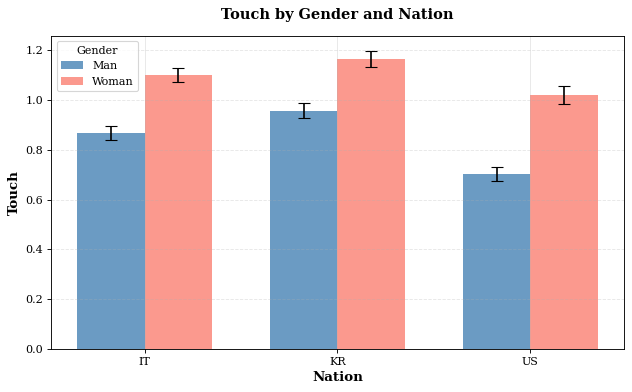


Analyzing: pose

ANOVA Results:
  Gender main effect: F=19.47, p=0.0000, η²p=0.034
  Nation main effect: F=47.56, p=0.0000, η²p=0.146
  Gender×Nation interaction: F=2.50, p=0.0832, η²p=0.009


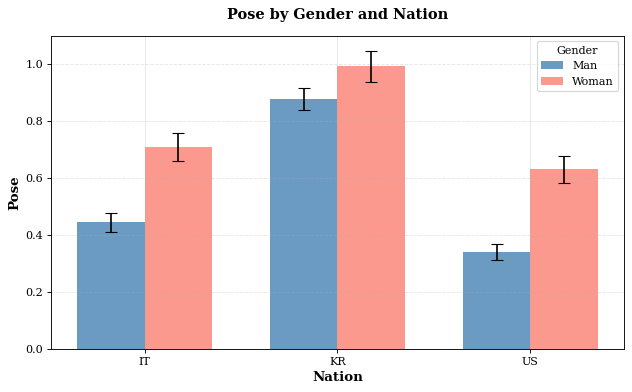


Analyzing: clothing_nudity

ANOVA Results:
  Gender main effect: F=47.98, p=0.0000, η²p=0.079
  Nation main effect: F=1.76, p=0.1729, η²p=0.006
  Gender×Nation interaction: F=1.08, p=0.3418, η²p=0.004


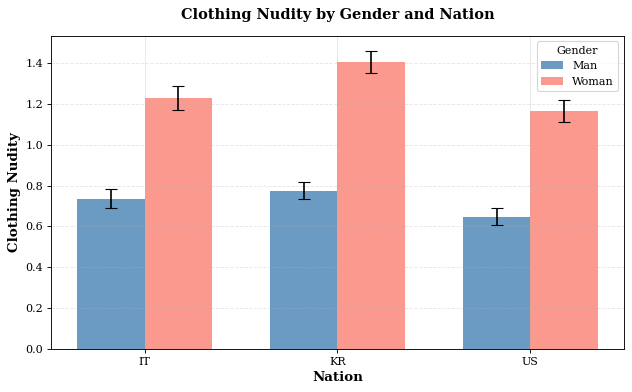


ANOVA SUMMARY TABLE (Partial Eta-Squared Effect Sizes)
             DV Gender_F Gender_p Gender_η² Nation_F Nation_p Nation_η² Interaction_F Interaction_p Interaction_η²
          touch    28.26   0.0000     0.048    18.09   0.0000     0.061          1.63        0.1966          0.006
           pose    19.47   0.0000     0.034    47.56   0.0000     0.146          2.50        0.0832          0.009
clothing_nudity    47.98   0.0000     0.079     1.76   0.1729     0.006          1.08        0.3418          0.004


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Define dependent variables to analyze
dv_list = [ 'touch', 'pose', 'clothing_nudity']

# Store results
anova_results = []
simple_effects_results = []

print("="*80)
print("TWO-WAY ANOVA: Gender × Nation Effects")
print("="*80)

for dv in dv_list:
    print(f"\n{'='*80}")
    print(f"Analyzing: {dv}")
    print(f"{'='*80}")

    # ===== STEP 1: TWO-WAY ANOVA =====
    model = ols(f'{dv} ~ C(gender) * C(nation)', data=user_df_binary_gender).fit()
    anova_table = anova_lm(model, typ=3)  # Type III SS for factorial designs

    # Extract effects
    gender_f = anova_table.loc['C(gender)', 'F']
    gender_p = anova_table.loc['C(gender)', 'PR(>F)']
    nation_f = anova_table.loc['C(nation)', 'F']
    nation_p = anova_table.loc['C(nation)', 'PR(>F)']
    interaction_f = anova_table.loc['C(gender):C(nation)', 'F']
    interaction_p = anova_table.loc['C(gender):C(nation)', 'PR(>F)']

    # Partial eta-squared (effect size)
    ss_gender = anova_table.loc['C(gender)', 'sum_sq']
    ss_nation = anova_table.loc['C(nation)', 'sum_sq']
    ss_interaction = anova_table.loc['C(gender):C(nation)', 'sum_sq']
    ss_residual = anova_table.loc['Residual', 'sum_sq']

    eta2_gender = ss_gender / (ss_gender + ss_residual)
    eta2_nation = ss_nation / (ss_nation + ss_residual)
    eta2_interaction = ss_interaction / (ss_interaction + ss_residual)

    # Store ANOVA results
    anova_results.append({
        'DV': dv,
        'Gender_F': f'{gender_f:.2f}',
        'Gender_p': f'{gender_p:.4f}',
        'Gender_η²': f'{eta2_gender:.3f}',
        'Nation_F': f'{nation_f:.2f}',
        'Nation_p': f'{nation_p:.4f}',
        'Nation_η²': f'{eta2_nation:.3f}',
        'Interaction_F': f'{interaction_f:.2f}',
        'Interaction_p': f'{interaction_p:.4f}',
        'Interaction_η²': f'{eta2_interaction:.3f}'
    })

    print(f"\nANOVA Results:")
    print(f"  Gender main effect: F={gender_f:.2f}, p={gender_p:.4f}, η²p={eta2_gender:.3f}")
    print(f"  Nation main effect: F={nation_f:.2f}, p={nation_p:.4f}, η²p={eta2_nation:.3f}")
    print(f"  Gender×Nation interaction: F={interaction_f:.2f}, p={interaction_p:.4f}, η²p={eta2_interaction:.3f}")

    # ===== STEP 2: SIMPLE EFFECTS (if interaction significant) =====
    if interaction_p < 0.05:
        print(f"\n⚠️ SIGNIFICANT INTERACTION (p={interaction_p:.4f}) → Testing simple effects")

        # Option A: Gender differences within each nation
        print("\n  Gender differences within nations:")
        for nation in ['it', 'kr', 'us']:
            subset = user_df_binary_gender[user_df_binary_gender['nation'] == nation]
            if len(subset) > 0:
                men = subset[subset['gender']=='man'][dv].dropna()
                women = subset[subset['gender']=='woman'][dv].dropna()

                # t-test
                t_stat, p_val = stats.ttest_ind(men, women, equal_var=False)  # Welch's t-test

                # Effect size (Cohen's d)
                n1, n2 = len(men), len(women)
                s1, s2 = men.std(), women.std()
                pooled_sd = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1 + n2 - 2))
                cohens_d = (men.mean() - women.mean()) / pooled_sd if pooled_sd > 0 else np.nan

                direction = "men > women" if men.mean() > women.mean() else "women > men"
                sig = "✓" if p_val < 0.05 else ""

                print(f"    {nation.upper()}: {direction} (Δ={abs(men.mean()-women.mean()):.2f}, d={cohens_d:.2f}, p={p_val:.3f}) {sig}")

                simple_effects_results.append({
                    'DV': dv,
                    'Comparison': f'Gender within {nation}',
                    'Mean_diff': f'{men.mean() - women.mean():.2f}',
                    'Cohen_d': f'{cohens_d:.2f}',
                    'p-value': f'{p_val:.4f}',
                    'Significant': 'Yes' if p_val < 0.05 else 'No'
                })

    # ===== STEP 3: VISUALIZATION (interaction plot) =====
    plt.figure(figsize=(8, 5))

    # Calculate means per cell
    means = user_df_binary_gender.groupby(['gender', 'nation'])[dv].mean().unstack()
    errors = user_df_binary_gender.groupby(['gender', 'nation'])[dv].sem().unstack()  # Standard error

    # Plot with gender on x-axis, separate lines for nations
    x = np.arange(len(means.columns))
    width = 0.35

    plt.bar(x - width/2, means.loc['man'], width, yerr=errors.loc['man'],
            label='Man', color='steelblue', capsize=5, alpha=0.8)
    plt.bar(x + width/2, means.loc['woman'], width, yerr=errors.loc['woman'],
            label='Woman', color='salmon', capsize=5, alpha=0.8)

    plt.xlabel('Nation', fontsize=12, fontweight='bold')
    plt.ylabel(dv.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    plt.title(f'{dv.replace("_", " ").title()} by Gender and Nation',
              fontsize=13, fontweight='bold', pad=15)
    plt.xticks(x, means.columns.str.upper())
    plt.legend(title='Gender', fontsize=10)
    plt.grid(axis='y', alpha=0.3, linestyle='--')

    # Add significance markers if interaction significant
    if interaction_p < 0.05:
        plt.text(0.5, 0.95, f'Interaction p={interaction_p:.3f}',
                 transform=plt.gca().transAxes, ha='center',
                 fontsize=10, fontweight='bold', color='red',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

# ===== STEP 4: SUMMARY TABLE =====
print("\n" + "="*80)
print("ANOVA SUMMARY TABLE (Partial Eta-Squared Effect Sizes)")
print("="*80)
anova_summary = pd.DataFrame(anova_results)
print(anova_summary.to_string(index=False))

if simple_effects_results:
    print("\n" + "="*80)
    print("SIMPLE EFFECTS (Gender Differences Within Nations)")
    print("="*80)
    simple_df = pd.DataFrame(simple_effects_results)
    print(simple_df.to_string(index=False))

TWO-WAY ANOVA: Gender × Nation Effects

Analyzing: touch

ANOVA Results:
  Gender main effect: F=28.26, p=0.0000, η²p=0.048
  Nation main effect: F=18.09, p=0.0000, η²p=0.061
  Gender×Nation interaction: F=1.63, p=0.1966, η²p=0.006

Analyzing: pose

ANOVA Results:
  Gender main effect: F=19.47, p=0.0000, η²p=0.034
  Nation main effect: F=47.56, p=0.0000, η²p=0.146
  Gender×Nation interaction: F=2.50, p=0.0832, η²p=0.009

Analyzing: clothing_nudity

ANOVA Results:
  Gender main effect: F=47.98, p=0.0000, η²p=0.079
  Nation main effect: F=1.76, p=0.1729, η²p=0.006
  Gender×Nation interaction: F=1.08, p=0.3418, η²p=0.004


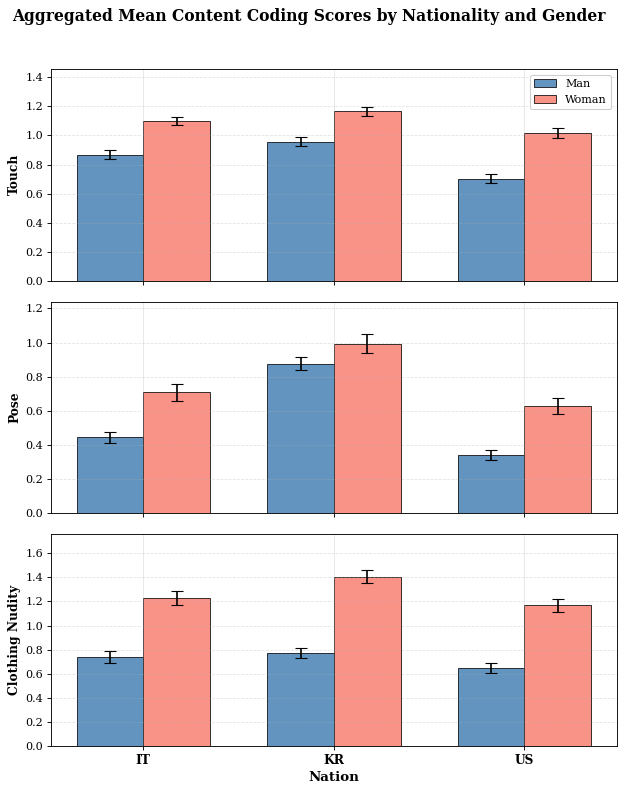


ANOVA SUMMARY TABLE (Partial Eta-Squared Effect Sizes)
             DV Gender_F Gender_p Gender_η² Nation_F Nation_p Nation_η² Interaction_F Interaction_p Interaction_η²
          touch    28.26   0.0000     0.048    18.09   0.0000     0.061          1.63        0.1966          0.006
           pose    19.47   0.0000     0.034    47.56   0.0000     0.146          2.50        0.0832          0.009
clothing_nudity    47.98   0.0000     0.079     1.76   0.1729     0.006          1.08        0.3418          0.004


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Define dependent variables to analyze
dv_list = ['touch', 'pose', 'clothing_nudity']

# Store results
anova_results = []

print("="*80)
print("TWO-WAY ANOVA: Gender × Nation Effects")
print("="*80)

# ===== STEP 1: RUN ANOVAs and collect results =====
for dv in dv_list:
    print(f"\n{'='*80}")
    print(f"Analyzing: {dv}")
    print(f"{'='*80}")

    model = ols(f'{dv} ~ C(gender) * C(nation)', data=user_df_binary_gender).fit()
    anova_table = anova_lm(model, typ=3)

    # Extract effects
    gender_f = anova_table.loc['C(gender)', 'F']
    gender_p = anova_table.loc['C(gender)', 'PR(>F)']
    nation_f = anova_table.loc['C(nation)', 'F']
    nation_p = anova_table.loc['C(nation)', 'PR(>F)']
    interaction_f = anova_table.loc['C(gender):C(nation)', 'F']
    interaction_p = anova_table.loc['C(gender):C(nation)', 'PR(>F)']

    # Partial eta-squared
    ss_gender = anova_table.loc['C(gender)', 'sum_sq']
    ss_nation = anova_table.loc['C(nation)', 'sum_sq']
    ss_interaction = anova_table.loc['C(gender):C(nation)', 'sum_sq']
    ss_residual = anova_table.loc['Residual', 'sum_sq']

    eta2_gender = ss_gender / (ss_gender + ss_residual)
    eta2_nation = ss_nation / (ss_nation + ss_residual)
    eta2_interaction = ss_interaction / (ss_interaction + ss_residual)

    anova_results.append({
        'DV': dv,
        'Gender_F': f'{gender_f:.2f}',
        'Gender_p': f'{gender_p:.4f}',
        'Gender_η²': f'{eta2_gender:.3f}',
        'Nation_F': f'{nation_f:.2f}',
        'Nation_p': f'{nation_p:.4f}',
        'Nation_η²': f'{eta2_nation:.3f}',
        'Interaction_F': f'{interaction_f:.2f}',
        'Interaction_p': f'{interaction_p:.4f}',
        'Interaction_η²': f'{eta2_interaction:.3f}'
    })

    print(f"\nANOVA Results:")
    print(f"  Gender main effect: F={gender_f:.2f}, p={gender_p:.4f}, η²p={eta2_gender:.3f}")
    print(f"  Nation main effect: F={nation_f:.2f}, p={nation_p:.4f}, η²p={eta2_nation:.3f}")
    print(f"  Gender×Nation interaction: F={interaction_f:.2f}, p={interaction_p:.4f}, η²p={eta2_interaction:.3f}")

# ===== STEP 2: CREATE STACKED VERTICAL PLOT =====
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)  # 3 rows, 1 column

for idx, dv in enumerate(dv_list):
    ax = axes[idx]

    # Calculate means per cell
    means = user_df_binary_gender.groupby(['gender', 'nation'])[dv].mean().unstack()
    errors = user_df_binary_gender.groupby(['gender', 'nation'])[dv].sem().unstack()

    # Plot with consistent styling
    x = np.arange(len(means.columns))
    width = 0.35

    ax.bar(x - width/2, means.loc['man'], width, yerr=errors.loc['man'],
           label='Man' if idx == 0 else '',  # Legend only on top plot
           color='steelblue', capsize=5, alpha=0.85, edgecolor='black', linewidth=0.8)
    ax.bar(x + width/2, means.loc['woman'], width, yerr=errors.loc['woman'],
           label='Woman' if idx == 0 else '',
           color='salmon', capsize=5, alpha=0.85, edgecolor='black', linewidth=0.8)

    # Labels and styling
    ax.set_ylabel(dv.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.35, linestyle='--', linewidth=0.7)
    ax.set_ylim(0, max(means.max().max() * 1.25, 0.5))  # Adaptive but consistent scaling

    # Add interaction significance marker (non-significant in your case)
    if interaction_p < 0.05:  # Will be False for your data
        ax.text(0.5, 0.92, f'Interaction p={interaction_p:.3f}',
                transform=ax.transAxes, ha='center', fontsize=9, fontweight='bold',
                color='red', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

# Shared x-axis settings (bottom plot only)
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(means.columns.str.upper(), fontsize=11, fontweight='bold')
axes[-1].set_xlabel('Nation', fontsize=12, fontweight='bold')

# Legend on top plot only
axes[0].legend(loc='upper right', fontsize=10, framealpha=0.95)

# Overall title
fig.suptitle('Aggregated Mean Content Coding Scores by Nationality and Gender',
             fontsize=14, fontweight='bold', y=0.995)

# Tight layout for LaTeX
plt.tight_layout(rect=[0, 0.01, 1, 0.97])  # Reserve space for suptitle
plt.savefig('gender_nation_stacked.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('gender_nation_stacked.pdf', bbox_inches='tight')  # Vector format for LaTeX
plt.show()

# ===== STEP 3: SUMMARY TABLE =====
print("\n" + "="*80)
print("ANOVA SUMMARY TABLE (Partial Eta-Squared Effect Sizes)")
print("="*80)
anova_summary = pd.DataFrame(anova_results)
print(anova_summary.to_string(index=False))

IndexError: index 3 is out of bounds for axis 0 with size 3

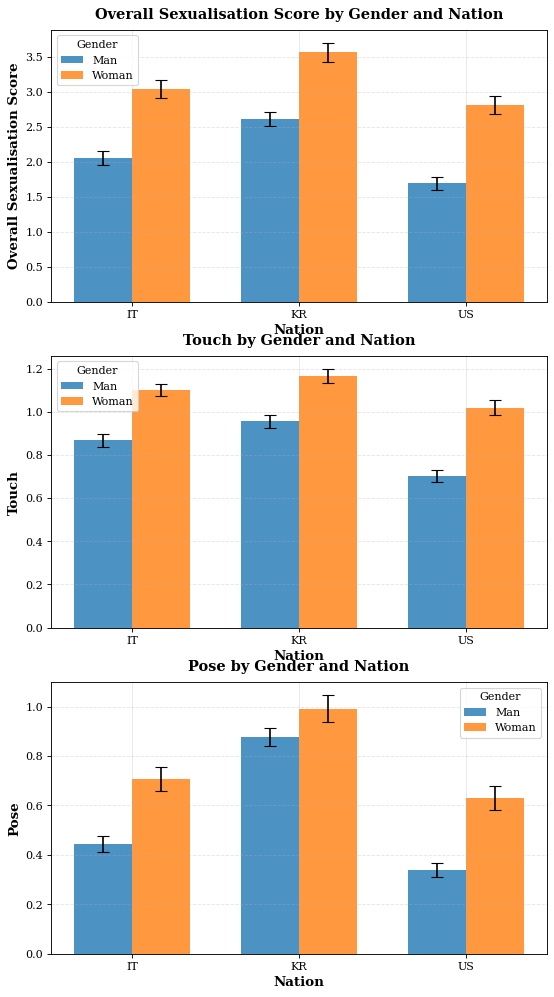

In [ ]:
# ===== STEP 3: VISUALIZATION (stacked plots) =====

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 15))  # 3 rows, 1 column

for i, dv in enumerate(dv_list):
    ax = axes[i]

    # Calculate means per cell
    means = user_df_binary_gender.groupby(['gender', 'nation'])[dv].mean().unstack()
    errors = user_df_binary_gender.groupby(['gender', 'nation'])[dv].sem().unstack()

    x = np.arange(len(means.columns))
    width = 0.35

    ax.bar(x - width/2, means.loc['man'], width, yerr=errors.loc['man'],
           label='Man', capsize=5, alpha=0.8)
    ax.bar(x + width/2, means.loc['woman'], width, yerr=errors.loc['woman'],
           label='Woman', capsize=5, alpha=0.8)

    ax.set_xlabel('Nation', fontsize=12, fontweight='bold')
    ax.set_ylabel(dv.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_title(f'{dv.replace("_", " ").title()} by Gender and Nation',
                 fontsize=13, fontweight='bold', pad=10)

    ax.set_xticks(x)
    ax.set_xticklabels(means.columns.str.upper())
    ax.legend(title='Gender', fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Optional: add interaction significance if you stored it
    interaction_p = float(anova_results[i]['Interaction_p'])
    if interaction_p < 0.05:
        ax.text(0.5, 0.9, f'Interaction p={interaction_p:.3f}',
                transform=ax.transAxes, ha='center',
                fontsize=10, fontweight='bold', color='red',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

##testing correlations

In [ ]:
cont_vars = [
    "touch",
    "pose",
    "clothing_nudity",
    "shares_per_play",
    "downloads_per_play",
    "comments_per_play",
]

In [ ]:
grouped_df = user_df_binary_gender.groupby('gender')

for name, group in grouped_df:
    print(f"\nCorrelations for gender: {name}")
    print(pg.pairwise_corr(
        group,
        cont_vars,
        method="pearson"
    ))



Correlations for gender: man
                     X                   Y   method alternative    n  \
0                touch                pose  pearson   two-sided  301   
1                touch     clothing_nudity  pearson   two-sided  301   
2                touch     shares_per_play  pearson   two-sided  301   
3                touch  downloads_per_play  pearson   two-sided  301   
4                touch   comments_per_play  pearson   two-sided  301   
5                 pose     clothing_nudity  pearson   two-sided  301   
6                 pose     shares_per_play  pearson   two-sided  301   
7                 pose  downloads_per_play  pearson   two-sided  301   
8                 pose   comments_per_play  pearson   two-sided  301   
9      clothing_nudity     shares_per_play  pearson   two-sided  301   
10     clothing_nudity  downloads_per_play  pearson   two-sided  301   
11     clothing_nudity   comments_per_play  pearson   two-sided  301   
12     shares_per_play  downloads_

In [ ]:
corr_men = user_df_binary_gender[user_df_binary_gender.gender=="man"][cont_vars].corr()
corr_women = user_df_binary_gender[user_df_binary_gender.gender=="woman"][cont_vars].corr()

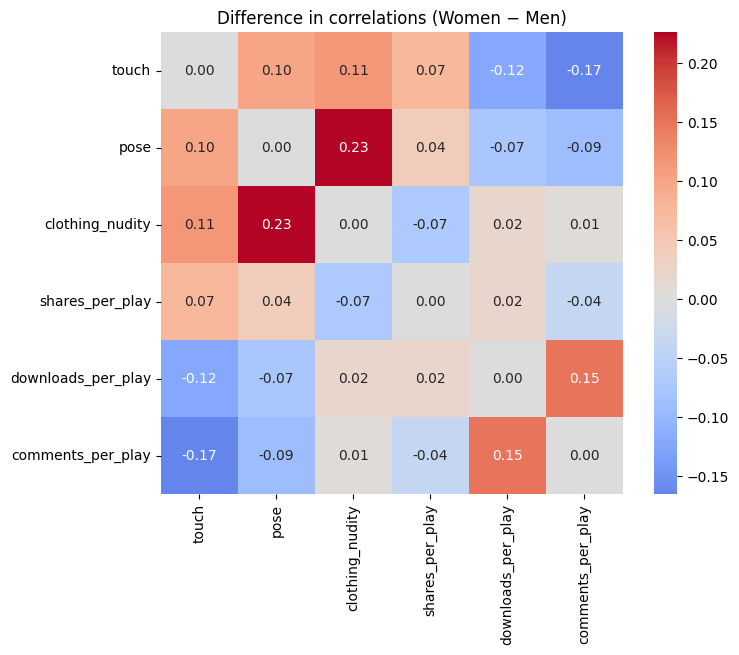

In [ ]:
corr_diff = corr_women - corr_men

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_diff,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    square=True
)

plt.title("Difference in correlations (Women − Men)")
plt.show()

## nationality

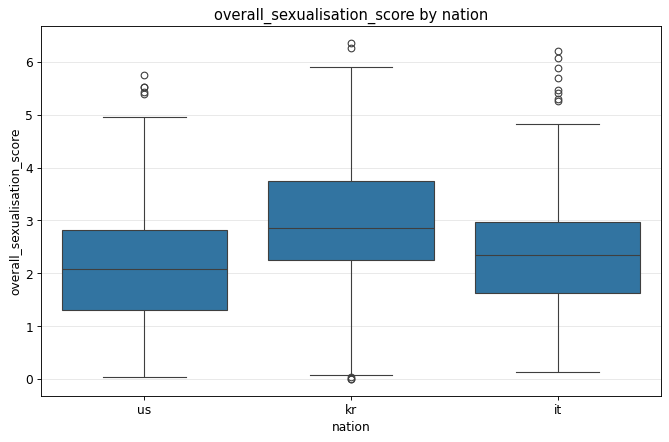

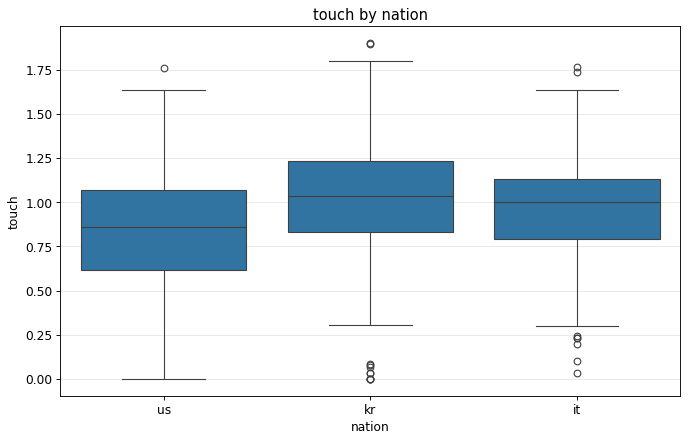

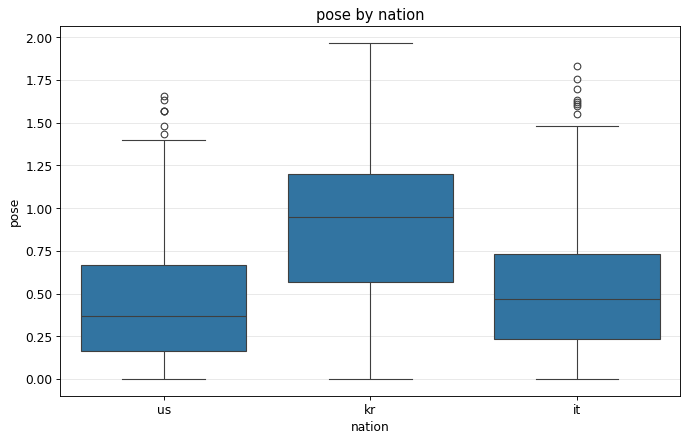

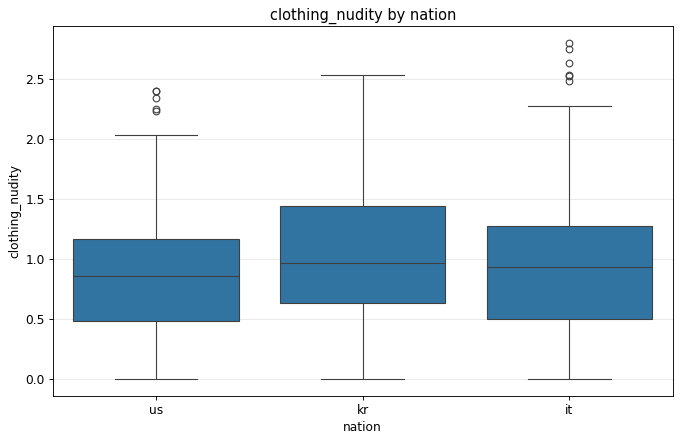

In [ ]:
feature_cols = ['overall_sexualisation_score', 'touch', 'pose', 'clothing_nudity']

for col in feature_cols:
    create_boxplot(user_summary, "nation", col)

In [ ]:
user_summary.nation.value_counts()

,count
nation,
us,212
kr,200
it,200


In [ ]:
df=user_summary.copy()

In [ ]:
df.nation.value_counts()

,count
nation,
us,212
kr,200
it,200


In [ ]:

from scipy.stats import f_oneway

# List of continuous variables to test
variables = [ 'touch', 'pose', 'clothing_nudity']

# Store results
results = []

for var in variables:
    # Extract data for each nation
    us_data = df[df['nation'] == 'us'][var]
    kr_data = df[df['nation'] == 'kr'][var]
    it_data = df[df['nation'] == 'it'][var]

    # Run ANOVA
    f_stat, p_value = f_oneway(us_data, kr_data, it_data)

    # Append results
    results.append({
        'variable': var,
        'F_statistic': f_stat,
        'p_value': p_value,
        'significant': p_value < 0.05
    })

# Create results DataFrame
anova_results = pd.DataFrame(results)
print(anova_results)

          variable  F_statistic       p_value  significant
0            touch    14.622388  6.271081e-07         True
1             pose    60.110766  1.497107e-24         True
2  clothing_nudity     4.517935  1.127975e-02         True


In [ ]:
# Verify nation labels and counts
print(df['nation'].value_counts())
print("\nSample means for 'pose':")
print(df.groupby('nation')['pose'].mean())

nation
us    212
kr    200
it    200
Name: count, dtype: int64

Sample means for 'pose':
nation
it    0.539826
kr    0.898021
us    0.461622
Name: pose, dtype: float64


In [ ]:

variables = [ 'touch', 'pose', 'clothing_nudity']

results = []

for var in variables:
    # 1. Get actual group means (for verification)
    group_means = df.groupby('nation')[var].mean().round(2)

    # 2. Run ANOVA
    model = ols(f'{var} ~ C(nation)', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    eta_squared = anova_table.loc['C(nation)', 'sum_sq'] / (
        anova_table.loc['C(nation)', 'sum_sq'] + anova_table.loc['Residual', 'sum_sq']
    )
    p_value = anova_table.loc['C(nation)', 'PR(>F)']

    # 3. Tukey HSD with CORRECT direction extraction
    tukey_str = "Not significant (p≥0.05)"
    if p_value < 0.05:
        tukey = pairwise_tukeyhsd(df[var], df['nation'])

        sig_pairs = []
        for row in tukey.summary().data[1:]:  # Skip header
            group1 = row[0]
            group2 = row[1]
            meandiff = row[4]  # CRITICAL: meandiff = mean(group2) - mean(group1)
            p_adj = row[5]

            if p_adj < 0.05:
                if meandiff > 0:
                    # group2 has higher mean
                    sig_pairs.append(f"{group2} > {group1} (Δ={meandiff:.2f})")
                else:
                    # group1 has higher mean
                    sig_pairs.append(f"{group1} > {group2} (Δ={abs(meandiff):.2f})")

        tukey_str = "; ".join(sig_pairs) if sig_pairs else "No significant pairs"

    # 4. Store results
    results.append({
        'variable': var,
        'eta_squared': round(eta_squared, 3),
        'effect_size': 'large' if eta_squared > 0.14 else ('medium' if eta_squared > 0.06 else 'small'),
        'sig_pairs': tukey_str,
        'KR_mean': group_means.get('kr', np.nan),
        'US_mean': group_means.get('us', np.nan),
        'IT_mean': group_means.get('it', np.nan)
    })

results_df = pd.DataFrame(results)
print(results_df[['variable', 'eta_squared', 'effect_size', 'sig_pairs', 'KR_mean', 'US_mean', 'IT_mean']])

          variable  eta_squared effect_size  \
0            touch        0.046       small   
1             pose        0.165       large   
2  clothing_nudity        0.015       small   

                            sig_pairs  KR_mean  US_mean  IT_mean  
0  it > us (Δ=0.19); kr > us (Δ=0.26)     1.02     0.84     0.95  
1  it > us (Δ=0.18); kr > us (Δ=0.54)     0.90     0.46     0.54  
2                    kr > us (Δ=0.29)     1.04     0.88     0.94  


#analyzing text


In [ ]:
%%capture
!pip install scikit_posthocs
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import spacy
from scipy.stats import chi2_contingency,kruskal, mannwhitneyu
from scikit_posthocs import posthoc_dunn

# Load spaCy model ONCE (run this first if not already loaded)
nlp = spacy.load("en_core_web_sm")

In [ ]:
text_df=df.copy()

In [ ]:
text_df=text_df.drop(columns=['username','id','create_time','video_url'])


In [ ]:
# ===== STEP 1: CREATE SEXUALIZATION BINS =====
text_df['sexualization_bin'] = pd.cut(
    text_df['overall_sexualisation_score'],
    bins=[-1, 2, 5, 11],  # -1 to include 0
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

# Verify bin distribution
print("Bin distribution:")
print(text_df['sexualization_bin'].value_counts().sort_index())


Bin distribution:
sexualization_bin
Low       10833
Medium     4191
High       2865
Name: count, dtype: int64


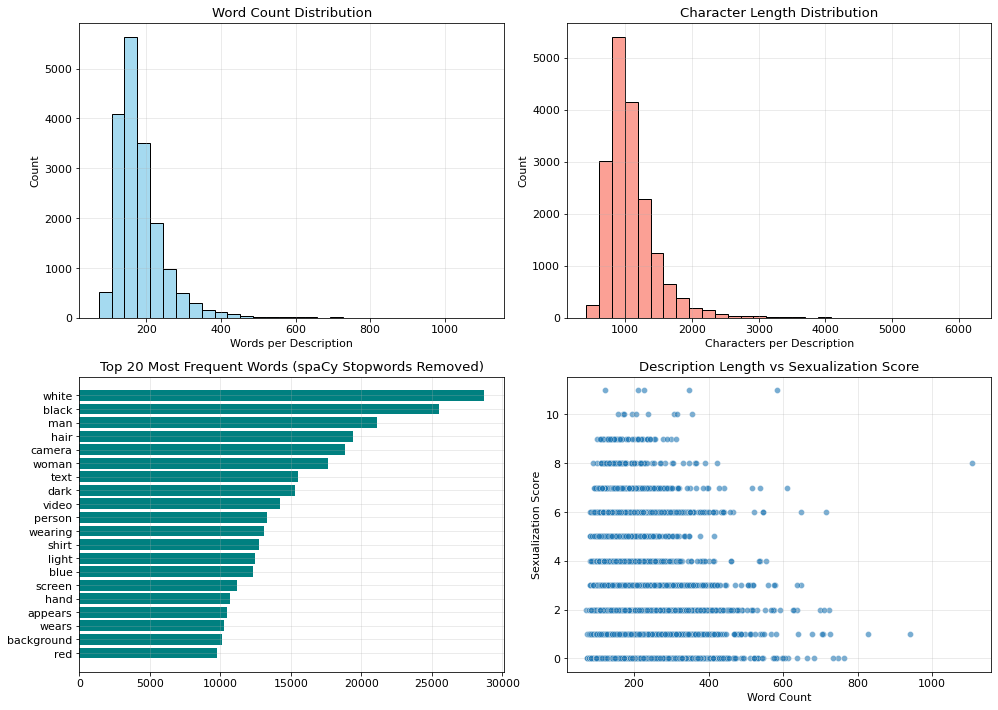

Total descriptions analyzed: 17889
Average words per description: 181.5
Median words: 166.0
Range: 72.0 - 1107.0 words

Stopwords used: 326 words from spaCy's English list


In [ ]:
try:
    stopwords = nlp.Defaults.stop_words  # spaCy's built-in English stopwords (~325 words)
except NameError:
    import spacy
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
    stopwords = nlp.Defaults.stop_words

text_df['word_count'] = text_df['Revised_Desc'].str.split().str.len()
text_df['char_count'] = text_df['Revised_Desc'].str.len()

# Plot distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10),dpi=72)

# 1. Word count distribution
sns.histplot(text_df['word_count'], bins=30, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Word Count Distribution')
axes[0,0].set_xlabel('Words per Description')

# 2. Character length distribution
sns.histplot(text_df['char_count'], bins=30, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Character Length Distribution')
axes[0,1].set_xlabel('Characters per Description')

# 3. Top 20 most frequent words (using spaCy stopwords)
all_words = ' '.join(text_df['Revised_Desc'].dropna()).lower()
words = re.findall(r'\b[a-z]{3,}\b', all_words)  # words ≥3 letters
filtered_words = [w for w in words if w not in stopwords]  # ← spaCy stopwords here
top_words = Counter(filtered_words).most_common(20)

axes[1,0].barh([w[0] for w in top_words], [w[1] for w in top_words], color='teal')
axes[1,0].set_title('Top 20 Most Frequent Words (spaCy Stopwords Removed)')
axes[1,0].invert_yaxis()

# 4. Word count vs sexualization score
sns.scatterplot(data=text_df, x='word_count', y='overall_sexualisation_score',
                alpha=0.6, ax=axes[1,1])
axes[1,1].set_title('Description Length vs Sexualization Score')
axes[1,1].set_xlabel('Word Count')
axes[1,1].set_ylabel('Sexualization Score')

plt.tight_layout()
plt.show()

# Key summary statistics
print(f"Total descriptions analyzed: {len(text_df)}")
print(f"Average words per description: {text_df['word_count'].mean():.1f}")
print(f"Median words: {text_df['word_count'].median()}")
print(f"Range: {text_df['word_count'].min()} - {text_df['word_count'].max()} words")
print(f"\nStopwords used: {len(stopwords)} words from spaCy's English list")

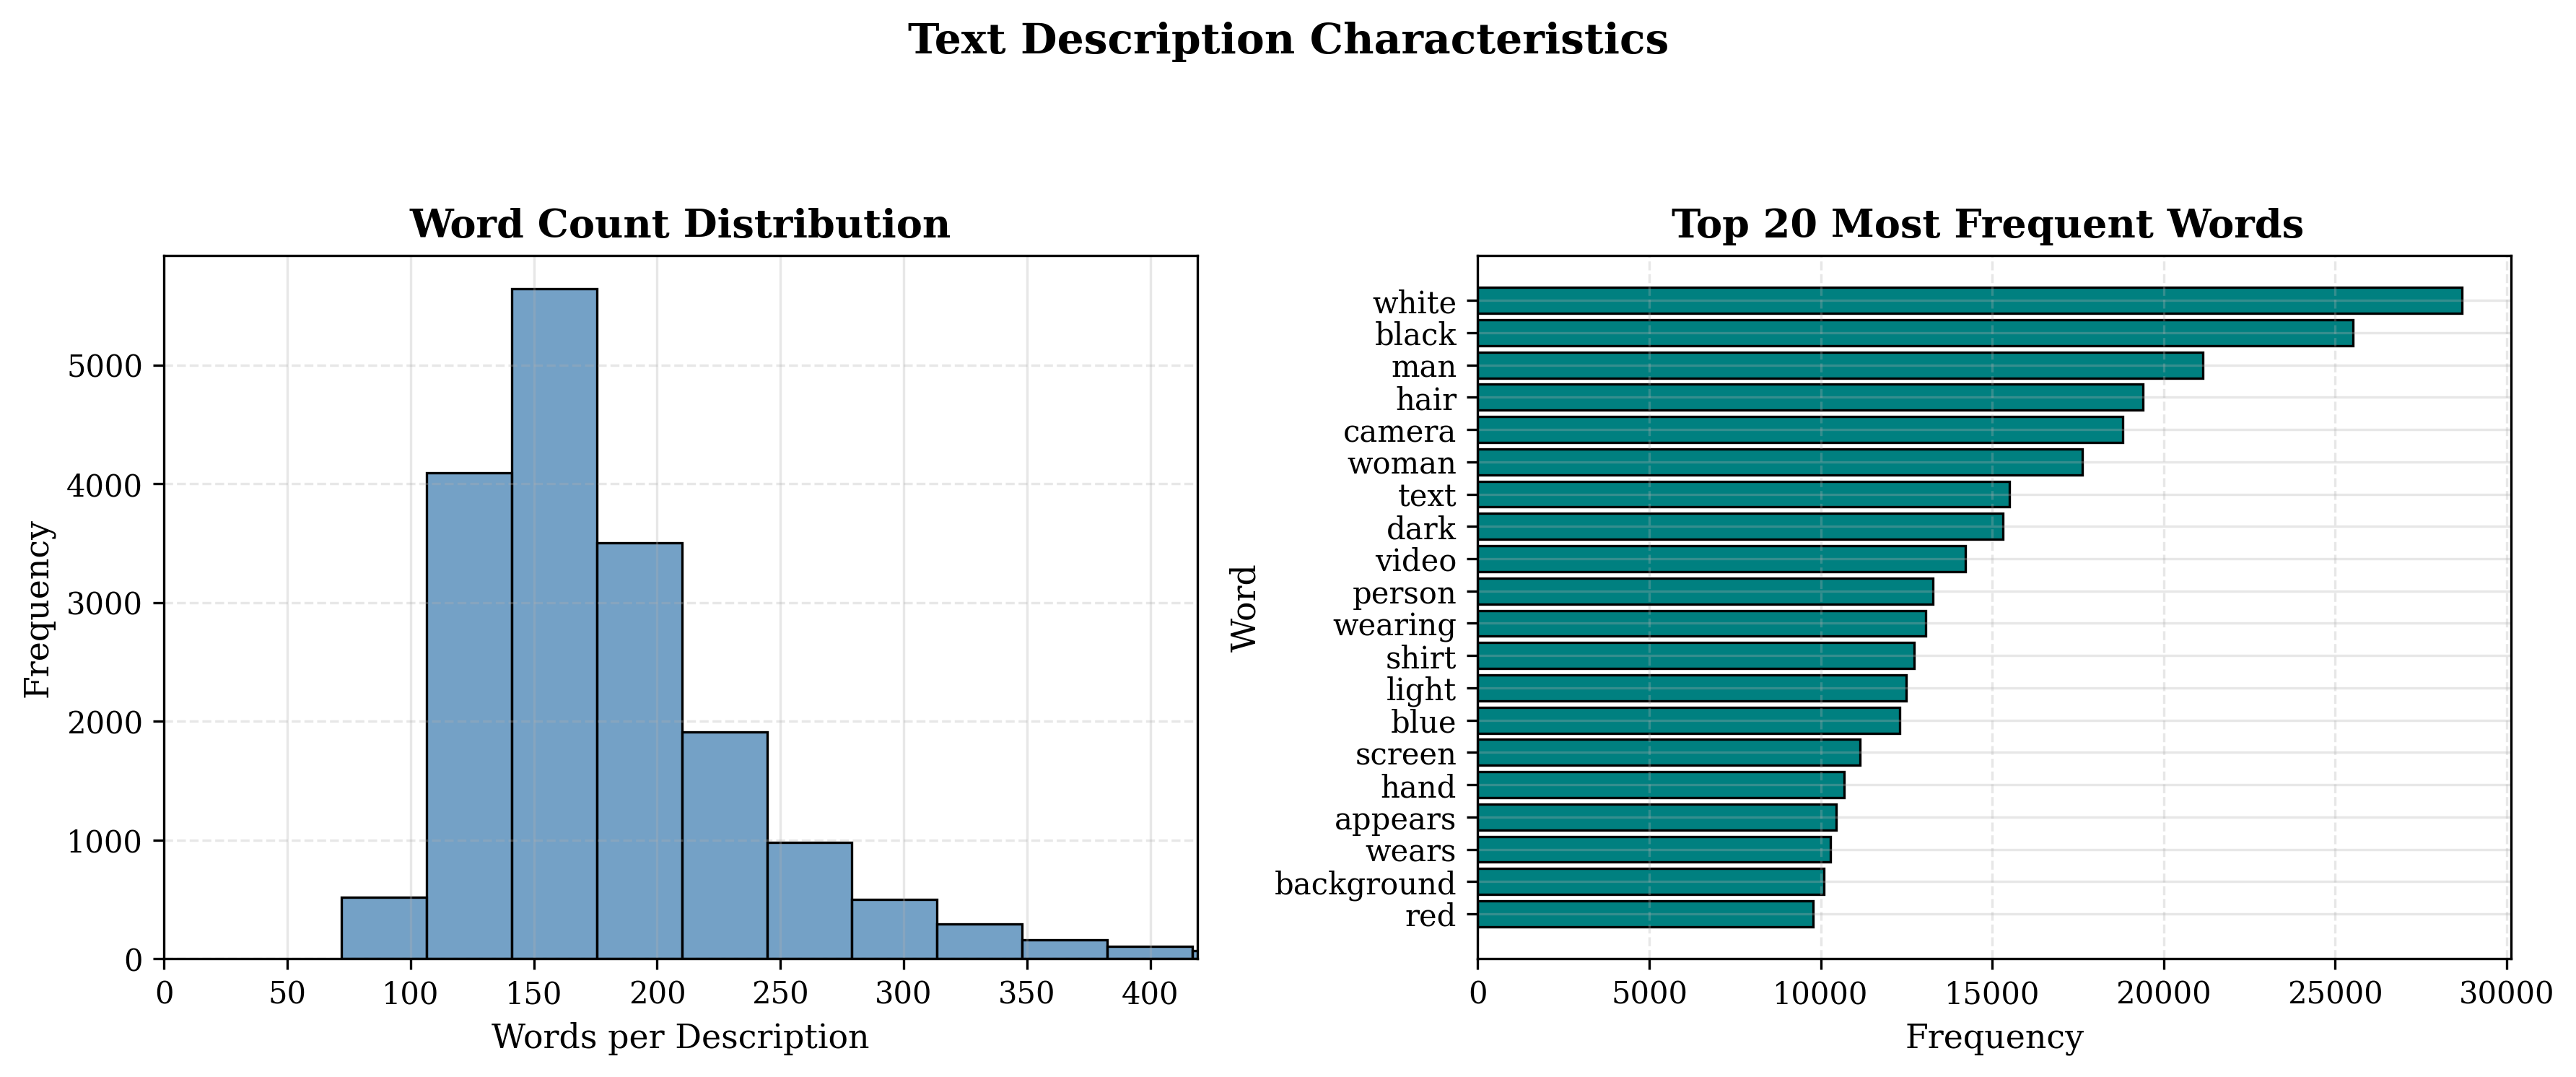

Total descriptions analyzed: 17,889
Average words per description: 181.5
Median words: 166.0
Range: 72.0 - 1107.0 words

Stopwords used: 326 from spaCy's English list
Top content words: white, black, man, hair, camera


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import spacy

# Load spaCy model
try:
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
except OSError:
    print("spaCy model not found. Installing...")
    !python -m spacy download en_core_web_sm
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

stopwords = nlp.Defaults.stop_words

# Compute text statistics
text_df['word_count'] = text_df['Revised_Desc'].str.split().str.len()

# Create horizontal 2-panel figure (optimized proportions)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)  # Wider than tall

# 1. Word count distribution (left panel)
sns.histplot(text_df['word_count'], bins=30, ax=axes[0], color='steelblue',
             edgecolor='black', linewidth=0.8)
axes[0].set_title('Word Count Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Words per Description', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_xlim(0, text_df['word_count'].quantile(0.99))  # Trim outliers

# 3. Top 20 content words (right panel)
all_words = ' '.join(text_df['Revised_Desc'].dropna()).lower()
words = re.findall(r'\b[a-z]{3,}\b', all_words)
filtered_words = [w for w in words if w not in stopwords]
top_words = Counter(filtered_words).most_common(20)

axes[1].barh([w[0] for w in top_words], [w[1] for w in top_words],
             color='teal', edgecolor='black', linewidth=0.8)
axes[1].set_title('Top 20 Most Frequent Words ', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frequency', fontsize=11)
axes[1].set_ylabel('Word', fontsize=11)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

# Overall title and layout
fig.suptitle('Text Description Characteristics',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0.01, 1, 0.92])  # Adjust for suptitle

# Save for LaTeX
plt.savefig('text_analysis_horizontal.pdf', bbox_inches='tight', dpi=300)
plt.savefig('text_analysis_horizontal.png', bbox_inches='tight', dpi=300, facecolor='white')
plt.show()

# Print summary statistics
print(f"Total descriptions analyzed: {len(text_df):,}")
print(f"Average words per description: {text_df['word_count'].mean():.1f}")
print(f"Median words: {text_df['word_count'].median()}")
print(f"Range: {text_df['word_count'].min()} - {text_df['word_count'].max()} words")
print(f"\nStopwords used: {len(stopwords)} from spaCy's English list")
print(f"Top content words: {', '.join([w[0] for w in top_words[:5]])}")

In [ ]:
# Check avg description length per bin
print(text_df.groupby('sexualization_bin')['word_count'].mean())

sexualization_bin
Low       187.483243
Medium    173.271838
High      171.130541
Name: word_count, dtype: float64


In [ ]:
# ===== STEP 1: BATCH LEMMATIZATION (FAST) =====
print("Lemmatizing all descriptions... (this may take 2-3 mins)")
docs = nlp.pipe(
    text_df['Revised_Desc'].fillna('').astype(str),
    batch_size=500,
    n_process=1  # Use 1 for stability; set to -1 to use all CPU cores if stable
)

# Store lemmatized tokens (lowercase, no stopwords) for ALL future analyses
text_df['lemmatized_tokens'] = [
    [token.lemma_.lower() for token in doc if not token.is_stop]
    for doc in docs
]
print(f"✓ Lemmatization complete! Sample: {text_df['lemmatized_tokens'].iloc[0][:5]}")

# ===== STEP 2: DEFINE BODY-PART GROUPS =====
body_parts = {
    'Torso': {'waist', 'hip', 'thigh', 'abdomen', 'stomach', 'chest', 'breast', 'back', 'shoulder'},
    'Limbs': {'arm', 'hand', 'finger', 'leg', 'foot', 'ankle', 'knee'},
    'Face': {'face', 'eye', 'lip', 'hair', 'mouth', 'cheek', 'chin'},
    'FullBody': {'body', 'figure', 'silhouette', 'posture'}
}

# ===== STEP 3: COUNT BODY PARTS FROM PRE-PROCESSED TOKENS =====
def count_body_parts_from_tokens(tokens, terms_set):
    """Count matches from already-lemmatized tokens"""
    if not isinstance(tokens, list):
        return 0
    return sum(1 for token in tokens if token in terms_set)

# Add counts (now INSTANT—uses pre-processed tokens)
for cat, terms_set in body_parts.items():
    text_df[f'{cat}_count'] = text_df['lemmatized_tokens'].apply(
        lambda tokens: count_body_parts_from_tokens(tokens, terms_set)
    )
    print(f"✓ {cat} counts added (mean: {text_df[f'{cat}_count'].mean():.2f})")

# ===== STEP 4: NORMALIZE (unchanged) =====
for cat in body_parts:
    text_df[f'{cat}_norm'] = (text_df[f'{cat}_count'] / text_df['word_count']) * 100

print("\n✓ Body-part analysis complete! Ready for visualization/stats.")

Lemmatizing all descriptions... (this may take 2-3 mins)
✓ Lemmatization complete! Sample: ['young', 'woman', 'long', 'dark', 'hair']
✓ Torso counts added (mean: 0.40)
✓ Limbs counts added (mean: 1.78)
✓ Face counts added (mean: 2.17)
✓ FullBody counts added (mean: 0.26)

✓ Body-part analysis complete! Ready for visualization/stats.


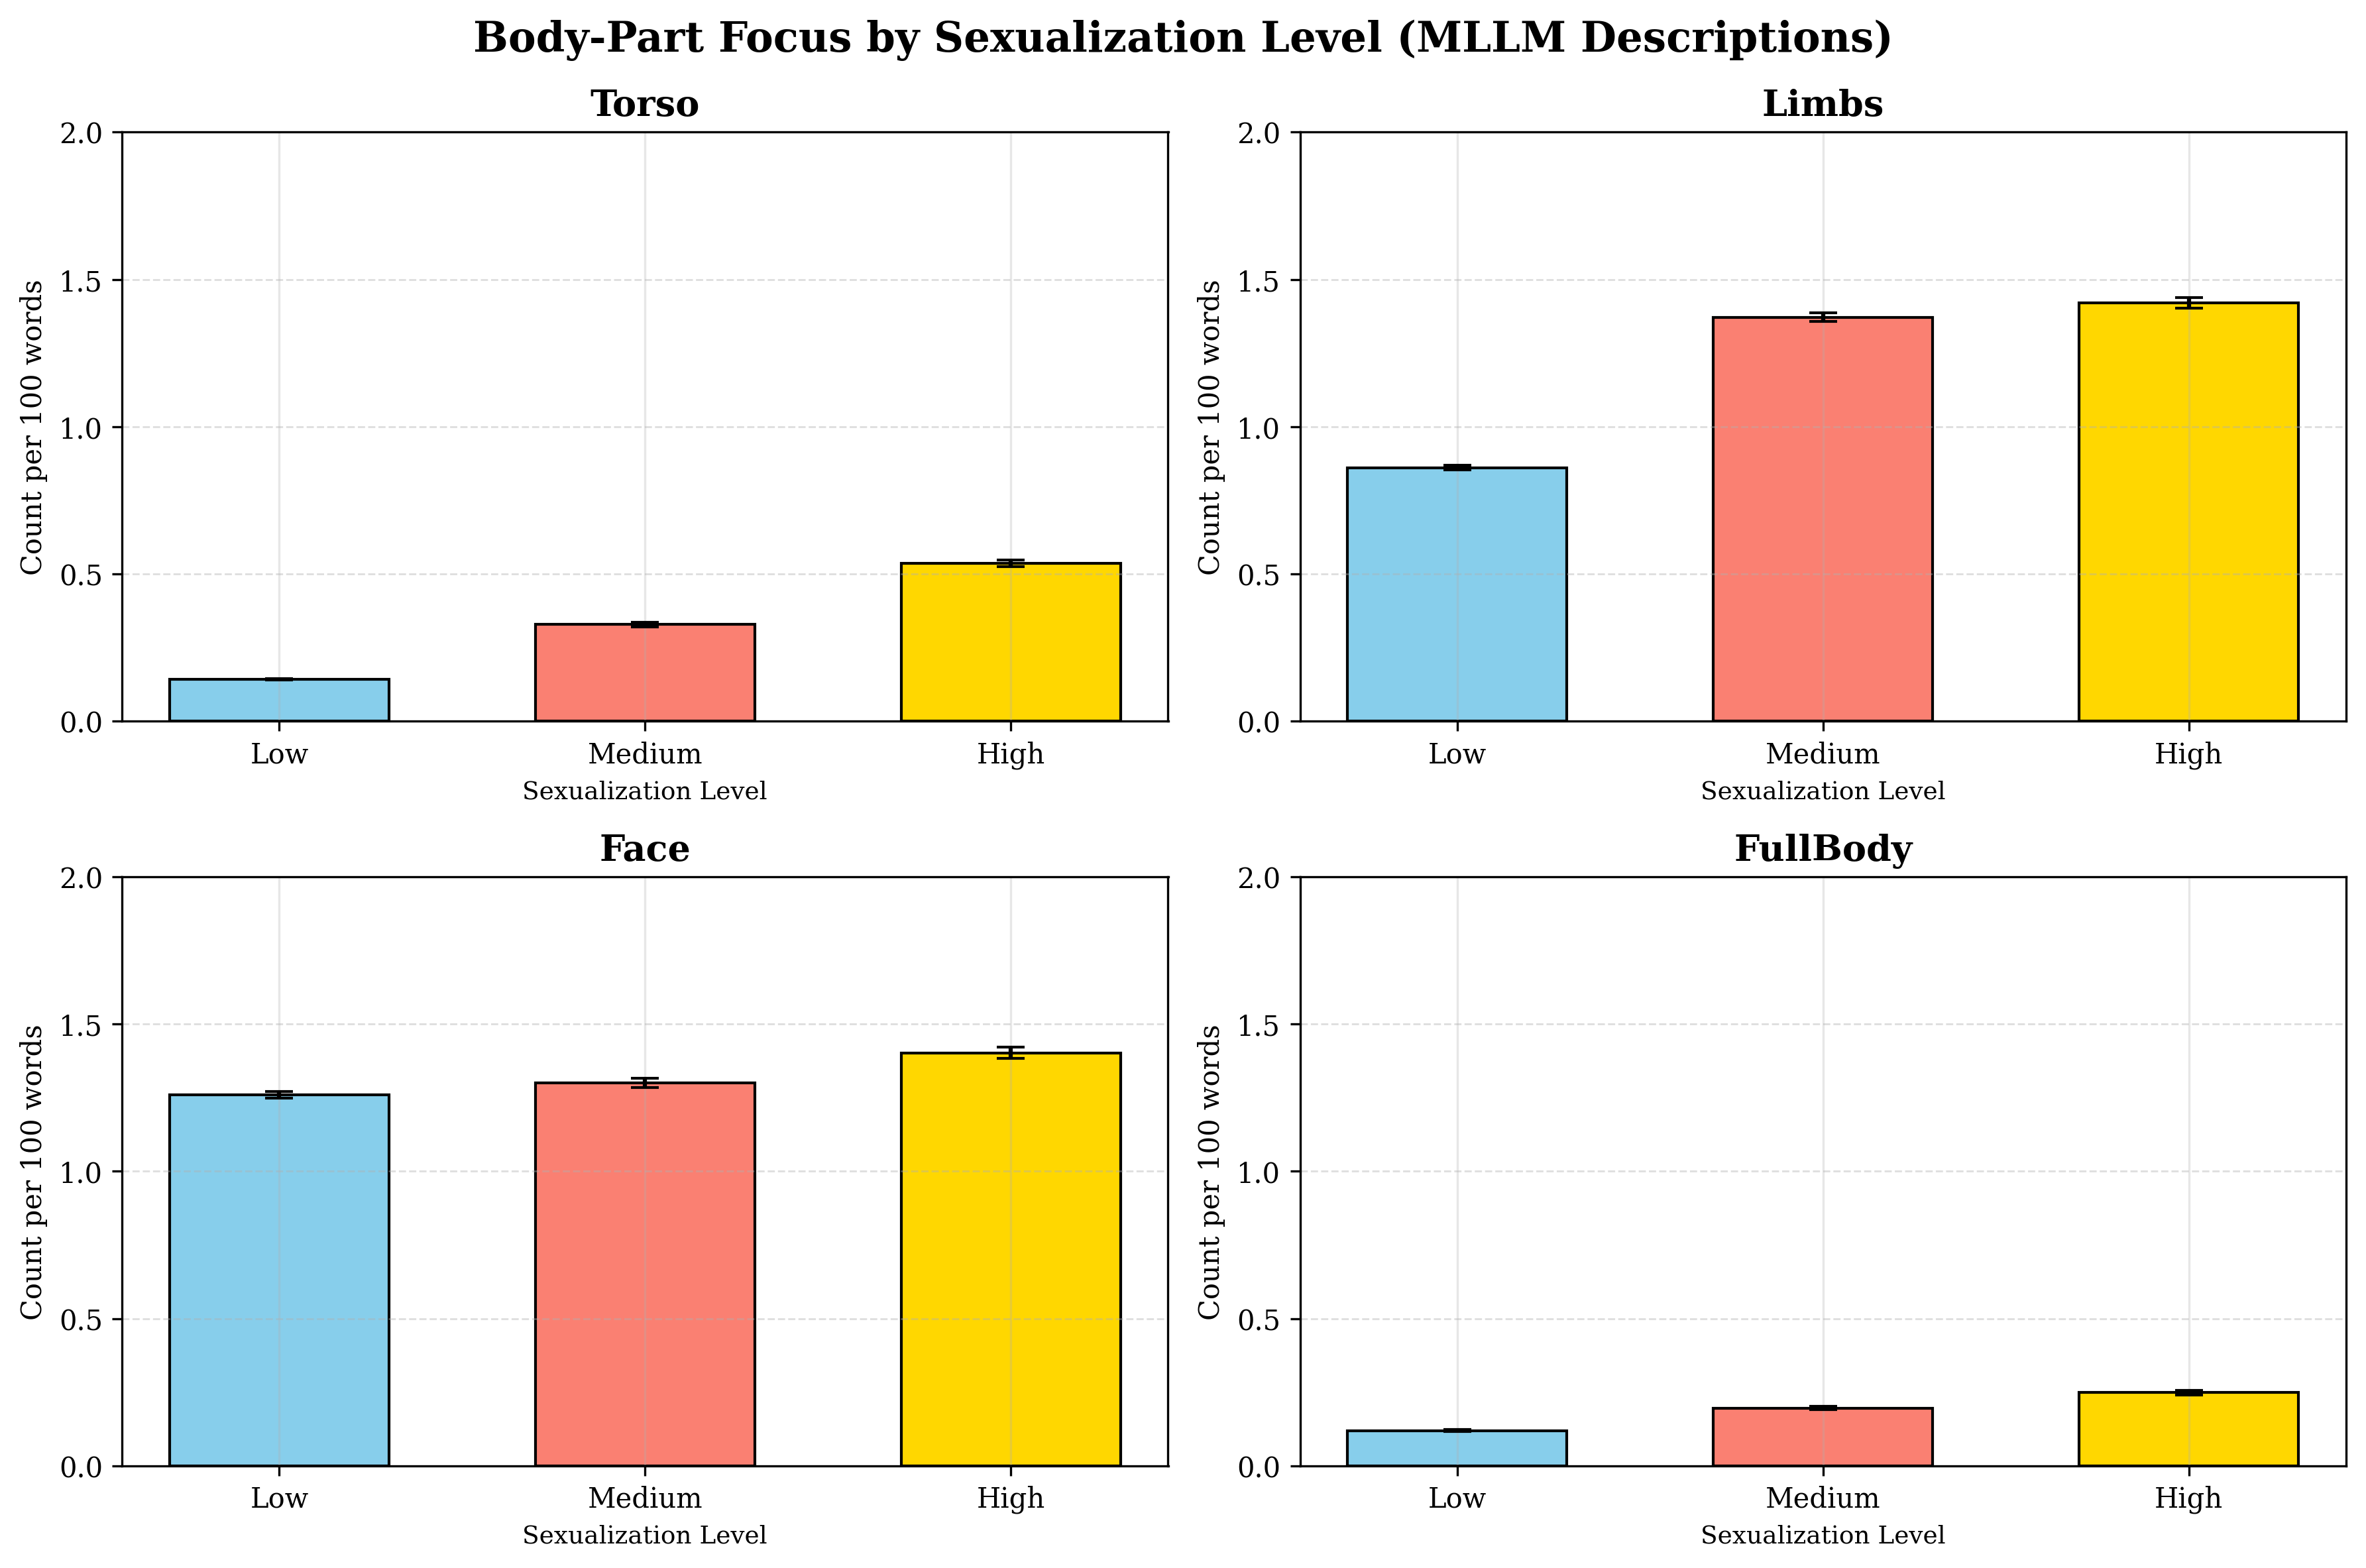


Kruskal-Wallis tests (body-part focus differences across bins):
  Torso     : χ² =  1896.0, p = 0.0000 ***
  Limbs     : χ² =  1577.5, p = 0.0000 ***
  Face      : χ² =   115.9, p = 0.0000 ***
  FullBody  : χ² =   438.1, p = 0.0000 ***


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kruskal

# CRITICAL FIX: Category names must match column names (no space in 'FullBody')
categories = ['Torso', 'Limbs', 'Face', 'FullBody']  # ← 'FullBody' not 'Full Body'
colors = {'Low': 'skyblue', 'Medium': 'salmon', 'High': 'gold'}

fig, axes = plt.subplots(2, 2, figsize=(12, 8),dpi=300)
axes = axes.flatten()

for i, cat in enumerate(categories):
    ax = axes[i]

    # Plot bars for each bin
    for bin_name in ['Low', 'Medium', 'High']:
        subset = text_df[text_df['sexualization_bin'] == bin_name]
        mean_norm = subset[f'{cat}_norm'].mean()
        std_err = subset[f'{cat}_norm'].std() / np.sqrt(len(subset))
        ax.bar(bin_name, mean_norm, yerr=std_err, color=colors[bin_name],
               capsize=5, edgecolor='black', linewidth=1.0, width=0.6)

    ax.set_title(cat, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count per 100 words', fontsize=10)
    ax.set_xlabel('Sexualization Level', fontsize=9)
    ax.grid(axis='y', alpha=0.4, linestyle='--', linewidth=0.7)

    # FIXED Y-AXIS RANGE (0 to 2) for fair cross-category comparison
    ax.set_ylim(0, 2.0)
    ax.set_yticks([0, 0.5, 1.0, 1.5, 2.0])  # Clean tick marks

plt.suptitle('Body-Part Focus by Sexualization Level (MLLM Descriptions)',
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Kruskal-Wallis tests
print("\nKruskal-Wallis tests (body-part focus differences across bins):")
for cat in categories:
    low = text_df[text_df['sexualization_bin']=='Low'][f'{cat}_norm'].dropna()
    med = text_df[text_df['sexualization_bin']=='Medium'][f'{cat}_norm'].dropna()
    high = text_df[text_df['sexualization_bin']=='High'][f'{cat}_norm'].dropna()
    stat, p = kruskal(low, med, high)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"  {cat:10s}: χ² = {stat:7.1f}, p = {p:.4f} {sig}")

In [ ]:


categories = ['Torso', 'Limbs', 'Face', 'FullBody']
bins = ['Low', 'Medium', 'High']
comparisons = [('Low', 'Medium'), ('Low', 'High'), ('Medium', 'High')]

results = []

for cat in categories:
    print(f"\n{'='*60}")
    print(f"Body Part: {cat}")
    print(f"{'='*60}")

    # Prepare long-format data for Dunn's test
    data = []
    for bin_name in bins:
        subset = text_df[text_df['sexualization_bin'] == bin_name]
        values = subset[f'{cat}_norm'].dropna().values
        for val in values:
            data.append({'bin': bin_name, 'value': val})
    df_long = pd.DataFrame(data)

    # Kruskal-Wallis (overall test)
    stat_kw, p_kw = kruskal(
        df_long[df_long['bin'] == 'Low']['value'],
        df_long[df_long['bin'] == 'Medium']['value'],
        df_long[df_long['bin'] == 'High']['value']
    )
    print(f"Kruskal-Wallis: H = {stat_kw:.1f}, p = {p_kw:.4f}")

    # Dunn's test (pairwise p-values)
    dunn_p = posthoc_dunn(df_long, val_col='value', group_col='bin', p_adjust='bonferroni')

    # Pairwise comparisons with effect sizes
    print("\nPairwise comparisons (Dunn's p-values + rank-biserial r):")
    for bin1, bin2 in comparisons:
        group1 = df_long[df_long['bin'] == bin1]['value'].values
        group2 = df_long[df_long['bin'] == bin2]['value'].values

        # Get Dunn's p-value
        p_val = dunn_p.loc[bin1, bin2]

        # Calculate rank-biserial correlation (effect size)
        u_stat, _ = mannwhitneyu(group1, group2, alternative='two-sided')
        n1, n2 = len(group1), len(group2)
        r = 1 - (2 * u_stat) / (n1 * n2)  # Formula: r = 1 - (2U)/(n₁n₂)

        # Magnitude interpretation
        r_abs = abs(r)
        if r_abs >= 0.5:
            magnitude = 'large'
        elif r_abs >= 0.3:
            magnitude = 'medium'
        elif r_abs >= 0.1:
            magnitude = 'small'
        else:
            magnitude = 'negligible'

        direction = '↑' if r > 0 else '↓'  # ↑ = bin2 > bin1

        print(f"  {bin1:12s} vs {bin2:12s} | r = {r:6.3f} ({magnitude:8s}, {direction}) | p = {p_val:.4f}")

        results.append({
            'Body Part': cat,
            'Comparison': f'{bin1} vs {bin2}',
            'Effect Size (r)': f'{r:.3f}',
            'Magnitude': magnitude,
            'Direction': direction,
            'p-value': f'{p_val:.4f}',
            'Significant': 'Yes' if p_val < 0.05 else 'No'
        })

# Summary table
print(f"\n{'='*70}")
print("SUMMARY: Dunn's Test + Rank-Biserial Effect Sizes")
print(f"{'='*70}\n")
summary_df = pd.DataFrame(results)
print(summary_df.to_string(index=False))

print("\nInterpretation:")
print("  • Effect size r: |r|≥0.1=small, |r|≥0.3=medium, |r|≥0.5=large")
print("  • Direction '↑' = second bin has HIGHER body-part focus")
print("  • Direction '↓' = second bin has LOWER body-part focus")


Body Part: Torso
Kruskal-Wallis: H = 1896.0, p = 0.0000

Pairwise comparisons (Dunn's p-values + rank-biserial r):
  Low          vs Medium       | r =  0.215 (small   , ↑) | p = 0.0000
  Low          vs High         | r =  0.399 (medium  , ↑) | p = 0.0000
  Medium       vs High         | r =  0.198 (small   , ↑) | p = 0.0000

Body Part: Limbs
Kruskal-Wallis: H = 1577.5, p = 0.0000

Pairwise comparisons (Dunn's p-values + rank-biserial r):
  Low          vs Medium       | r =  0.332 (medium  , ↑) | p = 0.0000
  Low          vs High         | r =  0.372 (medium  , ↑) | p = 0.0000
  Medium       vs High         | r =  0.032 (negligible, ↑) | p = 0.0259

Body Part: Face
Kruskal-Wallis: H = 115.9, p = 0.0000

Pairwise comparisons (Dunn's p-values + rank-biserial r):
  Low          vs Medium       | r =  0.056 (negligible, ↑) | p = 0.0000
  Low          vs High         | r =  0.125 (small   , ↑) | p = 0.0000
  Medium       vs High         | r =  0.071 (negligible, ↑) | p = 0.0000

Body Par

CONTENT WORD ANALYSIS: Log-Odds Ratios (All Non-Stopwords)

✓ Building word frequency table...
  → Analyzing 1476 content words (≥150 global occurrences)

✓ Overall lexical differences: χ²=83947.9, p=0.0000, Cramér's V=0.175 (small)

✓ Calculating log-odds ratios (High vs Low sexualization)...

✓ Generating visualization...


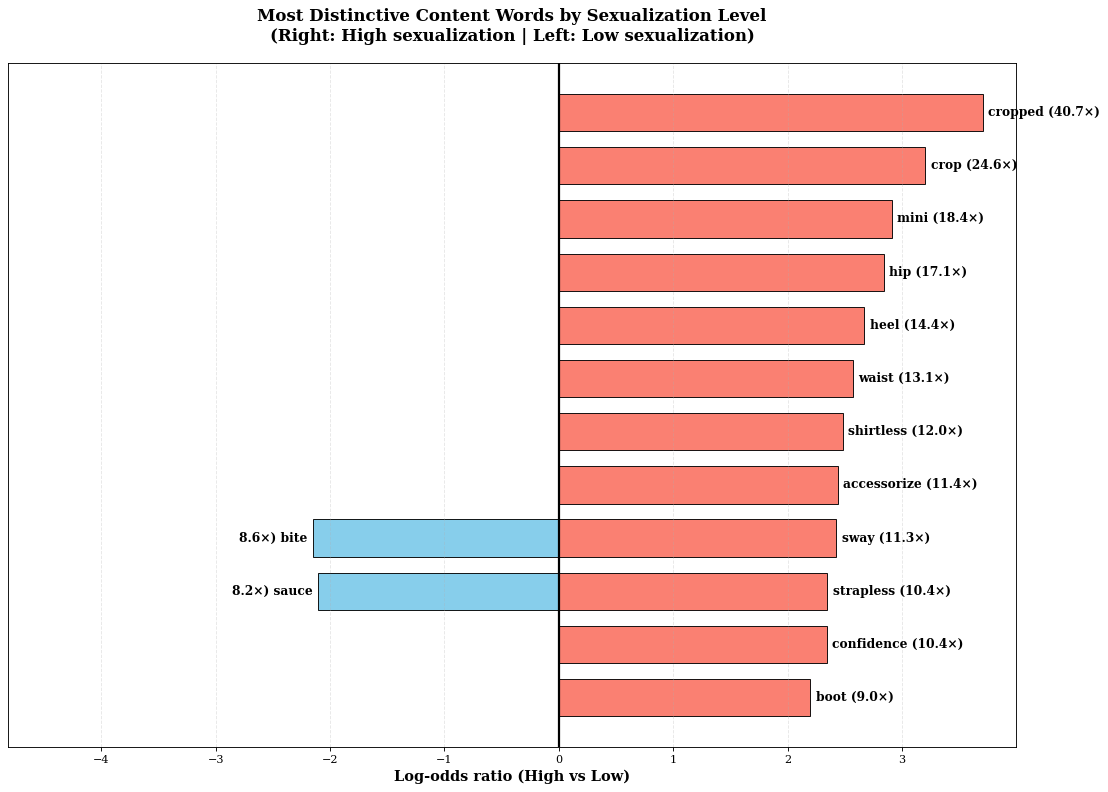


KEY FINDINGS: Distinctive Words

 Words MOST associated with HIGH sexualization (log-odds > 0.8):
   • 'cropped' appears 40.7× more frequently than in Low bin
   • 'crop' appears 24.6× more frequently than in Low bin
   • 'mini' appears 18.4× more frequently than in Low bin
   • 'hip' appears 17.1× more frequently than in Low bin
   • 'heel' appears 14.4× more frequently than in Low bin
   • 'waist' appears 13.1× more frequently than in Low bin
   • 'shirtless' appears 12.0× more frequently than in Low bin
   • 'accessorize' appears 11.4× more frequently than in Low bin
   • 'sway' appears 11.3× more frequently than in Low bin
   • 'strapless' appears 10.4× more frequently than in Low bin

 Words MOST associated with LOW sexualization (log-odds < -0.8):
   • 'bite' appears 8.6× more frequently than in High bin
   • 'sauce' appears 8.2× more frequently than in High bin
   • 'chicken' appears 6.8× more frequently than in High bin
   • 'taste' appears 6.1× more frequently than in High bi

In [ ]:

import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("CONTENT WORD ANALYSIS: Log-Odds Ratios (All Non-Stopwords)")
print("="*70)

# ===== STEP 0: ENSURE WE HAVE LEMMATIZED TOKENS =====
if 'lemmatized_tokens' not in text_df.columns:
    print("\n✓ Creating lemmatized tokens (non-stopwords)...")
    try:
        nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
    except:
        print("ERROR: Install spaCy model first: !python -m spacy download en_core_web_sm")
        raise

    # Batch process
    texts_clean = text_df['Revised_Desc'].fillna('').astype(str)
    docs = nlp.pipe(texts_clean, batch_size=200, n_process=1)

    text_df['lemmatized_tokens'] = [
        [token.lemma_.lower() for token in doc if not token.is_stop and len(token.lemma_) > 2]
        for doc in docs
    ]
    print(f"  → Created {len(text_df)} token lists (avg {text_df['lemmatized_tokens'].apply(len).mean():.1f} tokens/video)")

# ===== STEP 1: BUILD CONTINGENCY TABLE (WORDS × BINS) =====
print("\n✓ Building word frequency table...")
bin_names = ['Low', 'Medium', 'High']

# Get all words with sufficient global frequency
all_words_flat = [w for tokens in text_df['lemmatized_tokens'] for w in tokens]
word_freq = Counter(all_words_flat)
frequent_words = {w for w, c in word_freq.items() if c >= 150}  # Global threshold

# Build contingency table
contingency = []
word_labels = []
for word in frequent_words:
    counts = [
        sum(word in tokens for tokens in text_df[text_df['sexualization_bin']==bin]['lemmatized_tokens'])
        for bin in bin_names
    ]
    if min(counts) >= 5:  # Chi-square assumption
        contingency.append(counts)
        word_labels.append(word)

contingency_table = np.array(contingency)
print(f"  → Analyzing {len(word_labels)} content words (≥150 global occurrences)")

# ===== STEP 2: CHI-SQUARE + CRAMÉR'S V =====
chi2, p, dof, _ = chi2_contingency(contingency_table)
n = contingency_table.sum()
min_dim = min(contingency_table.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))

# Interpret effect size
v_label = "large" if cramers_v >= 0.5 else "medium" if cramers_v >= 0.3 else "small" if cramers_v >= 0.1 else "negligible"
print(f"\n✓ Overall lexical differences: χ²={chi2:.1f}, p={p:.4f}, Cramér's V={cramers_v:.3f} ({v_label})")

# ===== STEP 3: LOG-ODDS RATIOS (HIGH vs LOW) =====
print("\n✓ Calculating log-odds ratios (High vs Low sexualization)...")
bin_totals = [
    text_df[text_df['sexualization_bin']==bin]['lemmatized_tokens'].apply(len).sum()
    for bin in bin_names
]

word_log_odds = {}
for i, word in enumerate(word_labels):
    counts = contingency_table[i]
    # Laplace smoothing (+1) for stability
    p_high = (counts[2] + 1) / (bin_totals[2] + len(word_labels))
    p_low = (counts[0] + 1) / (bin_totals[0] + len(word_labels))
    word_log_odds[word] = np.log(p_high / p_low)

# Top distinctive words (absolute log-odds)
top_distinctive = sorted(word_log_odds.items(), key=lambda x: abs(x[1]), reverse=True)[:25]

# ===== STEP 4: VISUALIZATION =====
print("\n✓ Generating visualization...")

fig, ax = plt.subplots(figsize=(14, 10))

# Split into High-associated (positive) and Low-associated (negative)
high_words = [(w, lodds) for w, lodds in top_distinctive if lodds > 0][:12]
low_words = [(w, lodds) for w, lodds in top_distinctive if lodds < 0][:12]

# Plot High-associated (right side)
if high_words:
    words_h, lodds_h = zip(*sorted(high_words, key=lambda x: x[1]))  # Sort ascending for barh
    ax.barh(range(len(words_h)), lodds_h, color='salmon', edgecolor='black', linewidth=0.8, height=0.7)
    for i, (word, lodds) in enumerate(sorted(high_words, key=lambda x: x[1])):
        ratio = np.exp(lodds)
        ax.text(lodds + 0.05, i, f"{word} ({ratio:.1f}×)", va='center', fontsize=11, fontweight='bold')

# Plot Low-associated (left side)
if low_words:
    words_l, lodds_l = zip(*sorted(low_words, key=lambda x: x[1], reverse=True))  # Sort descending
    ax.barh(range(len(words_l), len(words_l)*2), lodds_l, color='skyblue', edgecolor='black', linewidth=0.8, height=0.7)
    for i, (word, lodds) in enumerate(sorted(low_words, key=lambda x: x[1], reverse=True)):
        ratio = np.exp(-lodds)
        ax.text(lodds - 0.05, i + len(words_l), f"{ratio:.1f}×) {word}", va='center', ha='right', fontsize=11, fontweight='bold')

# Formatting
ax.axvline(0, color='black', linestyle='-', linewidth=2)
ax.set_xlabel('Log-odds ratio (High vs Low)', fontsize=13, fontweight='bold')
ax.set_title('Most Distinctive Content Words by Sexualization Level\n'
             '(Right: High sexualization | Left: Low sexualization)',
             fontsize=15, fontweight='bold', pad=20)
ax.set_yticks([])
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_xlim(-max(abs(min(lodds_l)), max(lodds_h))*1.3 if low_words and high_words else None)

plt.tight_layout()
plt.show()

# ===== STEP 5: INTERPRETABLE SUMMARY =====
print("\n" + "="*70)
print("KEY FINDINGS: Distinctive Words")
print("="*70)

print("\n Words MOST associated with HIGH sexualization (log-odds > 0.8):")
for word, lodds in sorted(word_log_odds.items(), key=lambda x: x[1], reverse=True)[:10]:
    if lodds > 0.8:
        ratio = np.exp(lodds)
        print(f"   • '{word}' appears {ratio:.1f}× more frequently than in Low bin")

print("\n Words MOST associated with LOW sexualization (log-odds < -0.8):")
for word, lodds in sorted(word_log_odds.items(), key=lambda x: x[1])[:10]:
    if lodds < -0.8:
        ratio = np.exp(-lodds)
        print(f"   • '{word}' appears {ratio:.1f}× more frequently than in High bin")
print("\n" + "="*70)
print("METHODS NOTE FOR THESIS")
print("="*70)
print("• Content words: lemmatized tokens excluding spaCy stopwords (en_core_web_sm)")
print("• Bins: Low (0-2), Medium (3-5), High (6-11) sexualization scores")
print("• Distinctiveness measured via log-odds ratios (High vs Low bins)")
print("• Thresholds: words with ≥150 global occurrences and ≥5 per bin")
print("• Smoothing: Laplace (+1) applied to avoid division by zero")

✓ Saved: log_odds_lexical_signatures.{pdf,png}


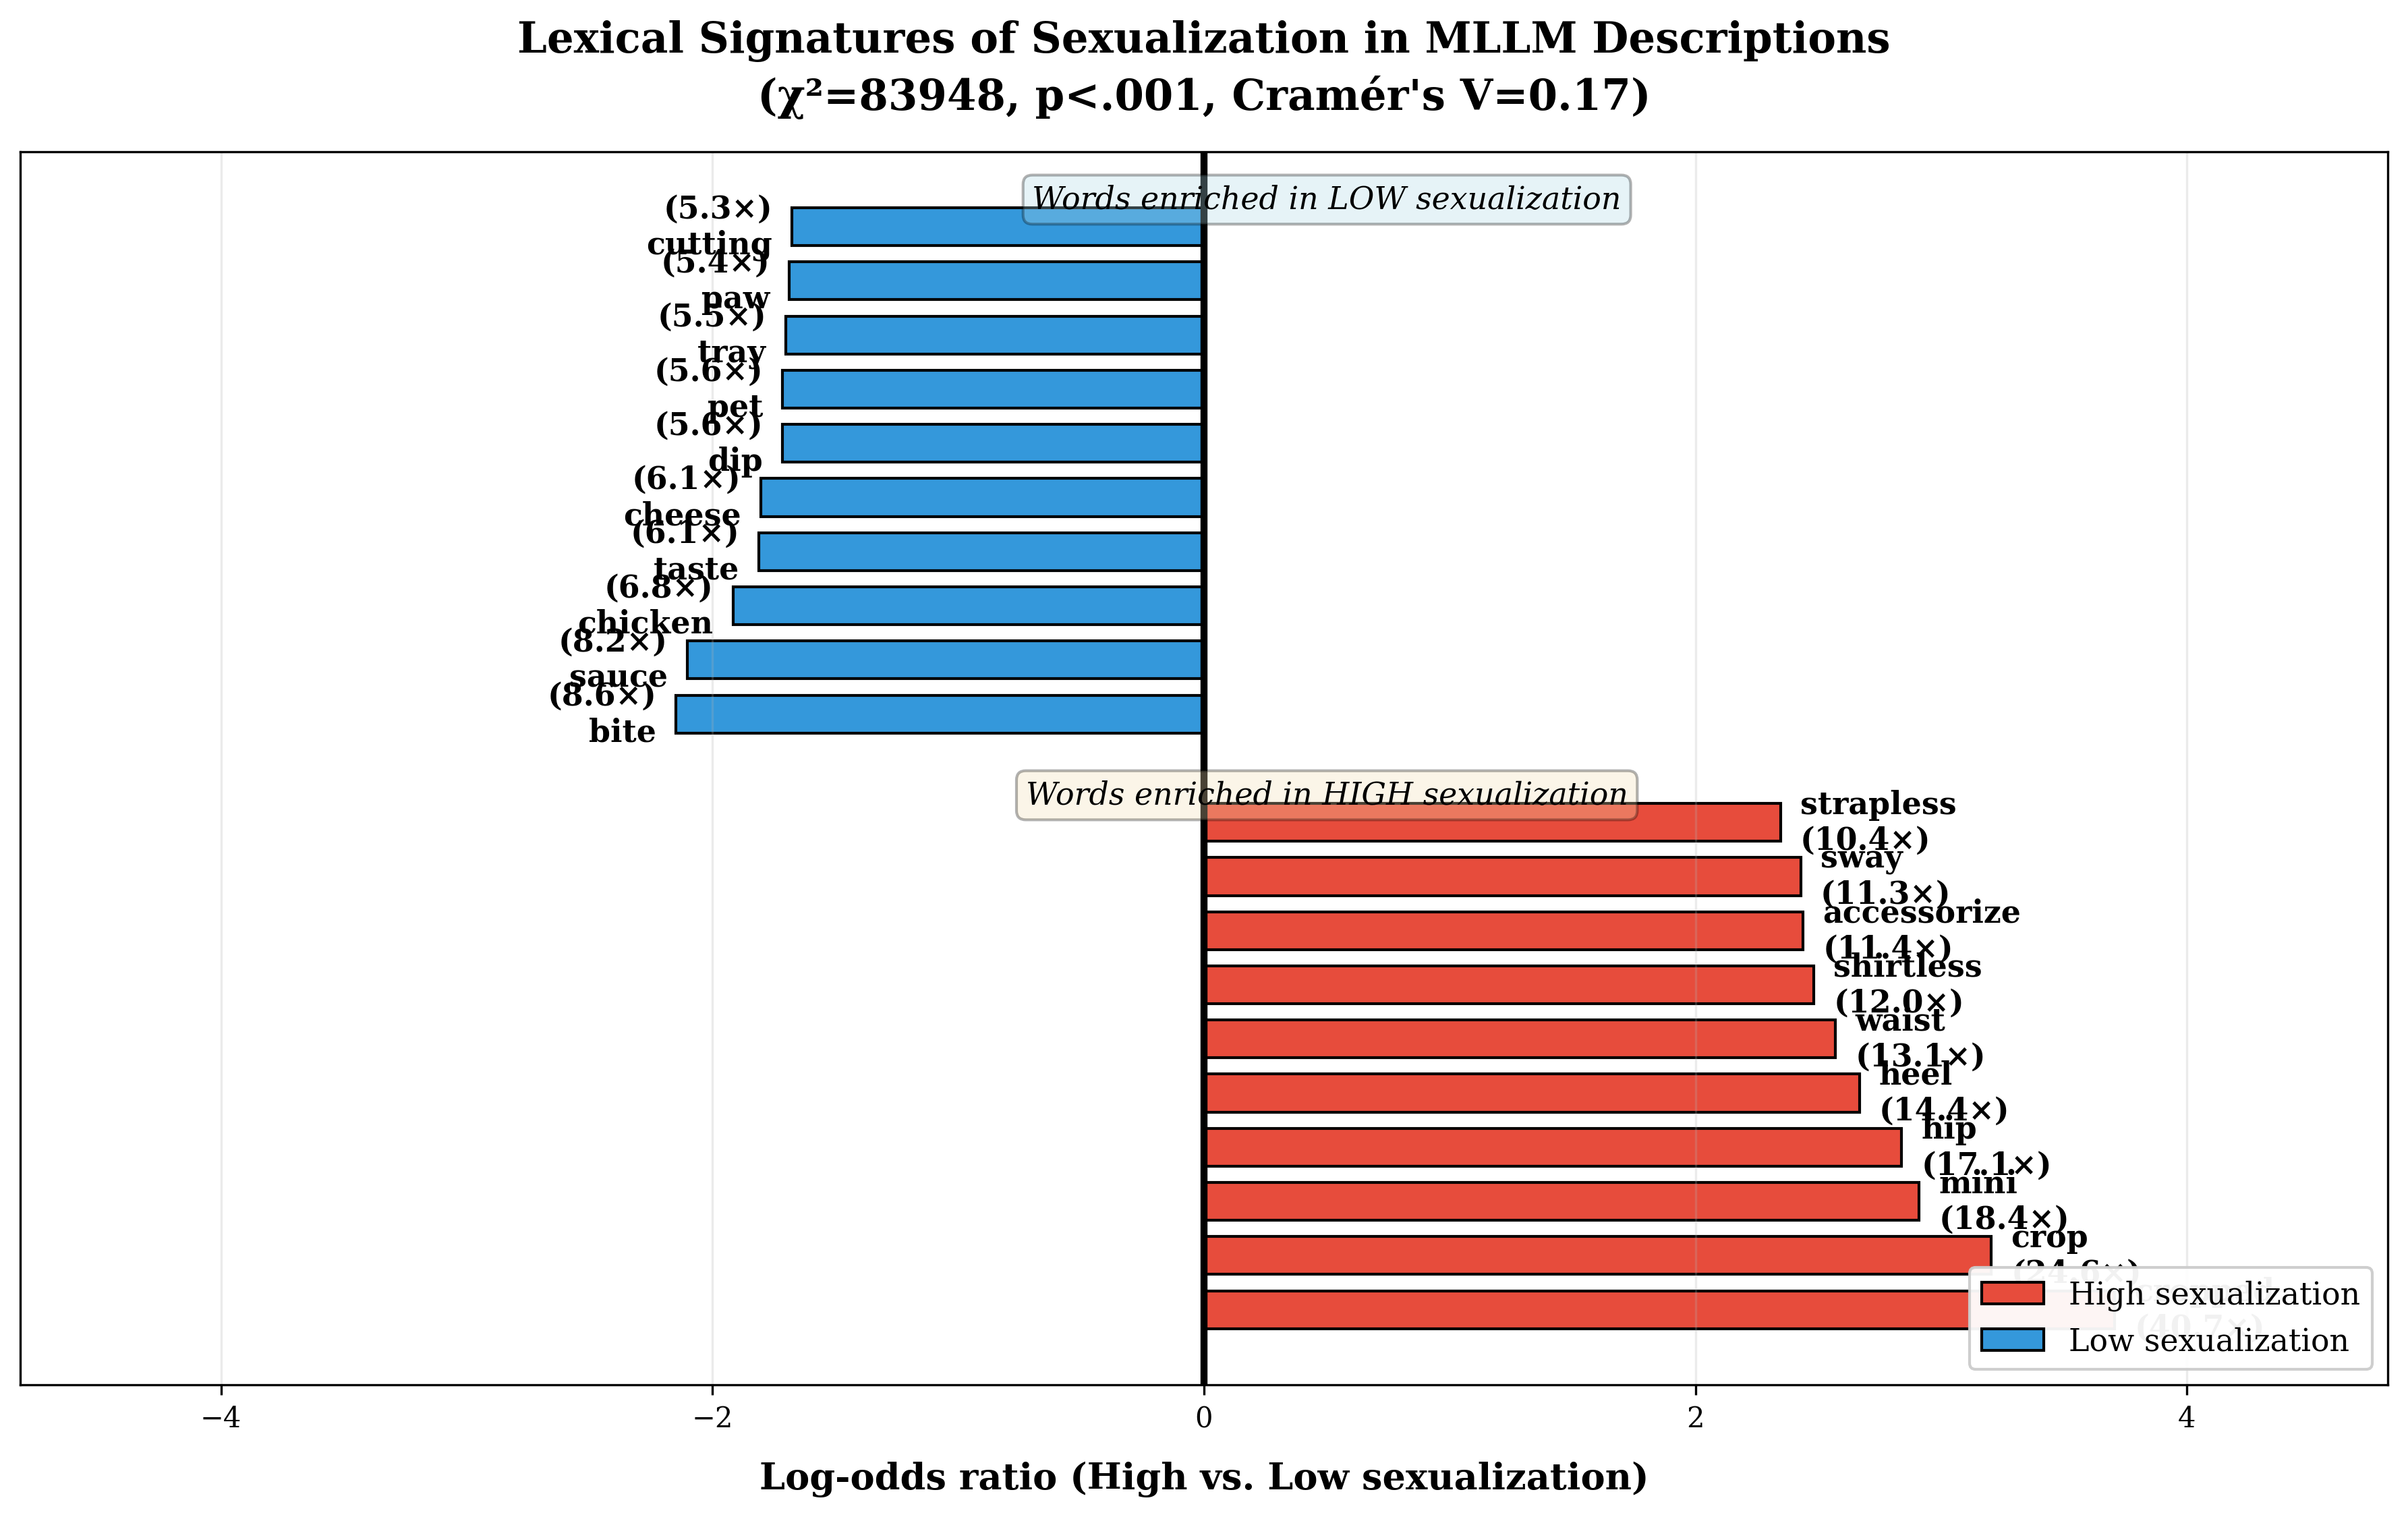

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency

# Recompute log-odds if needed (using your existing word_log_odds dict)
top_high = sorted([(w, lodds) for w, lodds in word_log_odds.items() if lodds > 0],
                  key=lambda x: x[1], reverse=True)[:10]
top_low = sorted([(w, lodds) for w, lodds in word_log_odds.items() if lodds < 0],
                 key=lambda x: x[1])[:10]  # Most negative first

# Create clean two-panel layout
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

# Plot High-associated words (right side)
y_high = np.arange(len(top_high))
lodds_high = [lodds for _, lodds in top_high]
words_high = [word for word, _ in top_high]
ratios_high = [np.exp(lodds) for lodds in lodds_high]

bars_high = ax.barh(y_high, lodds_high, color='#E74C3C', edgecolor='black',
                    linewidth=1.0, height=0.7, label='High sexualization')
for i, (word, lodds, ratio) in enumerate(zip(words_high, lodds_high, ratios_high)):
    ax.text(lodds + 0.08, i, f'{word}\n({ratio:.1f}×)', va='center', ha='left',
            fontsize=11, fontweight='bold')

# Plot Low-associated words (left side)
y_low = np.arange(len(top_low)) + len(top_high) + 1  # Gap between sections
lodds_low = [lodds for _, lodds in top_low]
words_low = [word for word, _ in top_low]
ratios_low = [np.exp(-lodds) for lodds in lodds_low]  # Positive ratio for Low words

bars_low = ax.barh(y_low, lodds_low, color='#3498DB', edgecolor='black',
                   linewidth=1.0, height=0.7, label='Low sexualization')
for i, (word, lodds, ratio) in enumerate(zip(words_low, lodds_low, ratios_low)):
    ax.text(lodds - 0.08, y_low[i], f'({ratio:.1f}×)\n{word}', va='center', ha='right',
            fontsize=11, fontweight='bold')

# Formatting
ax.axvline(0, color='black', linestyle='-', linewidth=2.5)
ax.set_xlabel('Log-odds ratio (High vs. Low sexualization)', fontsize=13, fontweight='bold', labelpad=10)
ax.set_title('Lexical Signatures of Sexualization in MLLM Descriptions\n'
             f'(χ²={chi2:.0f}, p<.001, Cramér\'s V={cramers_v:.2f})',
             fontsize=15, fontweight='bold', pad=15, linespacing=1.4)
ax.set_yticks([])
ax.grid(axis='x', alpha=0.25, linestyle='-', linewidth=0.8)
ax.legend(loc='lower right', fontsize=11, framealpha=0.95)

# Add section labels
ax.text(0.5, len(top_high)-0.5, 'Words enriched in HIGH sexualization',
        ha='center', va='center', fontsize=11, style='italic',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax.text(0.5, y_low[-1]+0.5, 'Words enriched in LOW sexualization',
        ha='center', va='center', fontsize=11, style='italic',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

# Set symmetrical x-limits for visual balance
max_lodds = max(max(lodds_high), abs(min(lodds_low)))
ax.set_xlim(-max_lodds*1.3, max_lodds*1.3)

plt.tight_layout(rect=[0, 0.01, 1, 0.96])
plt.savefig('log_odds_lexical_signatures.pdf', bbox_inches='tight', dpi=300)
plt.savefig('log_odds_lexical_signatures.png', bbox_inches='tight', dpi=300, facecolor='white')
print("✓ Saved: log_odds_lexical_signatures.{pdf,png}")
plt.show()